# Tensor Network Lanczos Exploration

This notebook explores whether **Tensor Train (TT)** and **Quantized TT (QTT)** methods
can accelerate the Lanczos-based Klein–Gordon propagation for electron microscopy.

## Key questions
1. Can the electrostatic potential be compressed efficiently in TT/QTT form?
2. Does the wavefunction remain low-rank during propagation?
3. Can we build the Helmholtz operator $A = -\Delta - k_0^2 n^2(x,y)$ as a low-rank MPO?
4. Does TT-Lanczos provide a speedup over standard FFT-based Lanczos?

### Why Lanczos + TT?
- The Laplacian is a sum of Kronecker products → **low TT rank**
- No alternating FFT/real-space domains → **preserves locality**
- Repeated structured operator application → **compatible with TT truncation**

### Roadmap
1. Core TT arithmetic (from scratch, NumPy)
2. Compress the potential → measure TT ranks
3. Compress exit wavefunctions from standard Lanczos
4. Build Helmholtz operator as TT/MPO
5. TT-Lanczos prototype
6. Rank growth diagnostics

In [2]:
%matplotlib widget

import os
import functools
from time import perf_counter

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".1"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk, surface
from matplotlib.colors import LogNorm
from scipy.linalg import svdvals

from wide_angle_propagation.wpm import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
)
from wide_angle_propagation.klein_gordon import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## 1. Core TT Arithmetic

A tensor $T(i_1, \ldots, i_d)$ in **Tensor Train** form is:
$$T(i_1, \ldots, i_d) = G_1(i_1) \, G_2(i_2) \cdots G_d(i_d)$$
where each $G_k(i_k)$ is an $r_{k-1} \times r_k$ matrix, and $r_0 = r_d = 1$.

The internal dimensions $r_k$ are the **TT ranks**. Low ranks = efficient compression.

We implement basic TT operations from scratch to avoid external dependencies.

In [3]:
# =====================================================================
# Core TT decomposition and arithmetic
# =====================================================================

def tt_decompose(tensor, max_rank=None, tol=1e-12):
    """Decompose a d-dimensional tensor into TT format via sequential SVD.

    Parameters
    ----------
    tensor : ndarray, shape (n_1, n_2, ..., n_d)
    max_rank : int or None
        Hard cap on TT ranks.
    tol : float
        Relative truncation tolerance (Frobenius norm).

    Returns
    -------
    cores : list of ndarray
        cores[k] has shape (r_{k-1}, n_k, r_k).
    """
    shape = tensor.shape
    d = len(shape)
    cores = []
    C = tensor.reshape(shape[0], -1).copy()
    r_prev = 1

    norm_full = np.linalg.norm(C)
    eps = tol * norm_full / np.sqrt(d - 1) if norm_full > 0 else 0.0

    for k in range(d - 1):
        nk = shape[k]
        C = C.reshape(r_prev * nk, -1)
        U, S, Vh = np.linalg.svd(C, full_matrices=False)

        # Truncate
        if eps > 0:
            cumsum = np.cumsum(S[::-1] ** 2)
            keep = np.searchsorted(cumsum, eps ** 2) + 1
            r_new = max(1, len(S) - keep + 1)
        else:
            r_new = len(S)

        if max_rank is not None:
            r_new = min(r_new, max_rank)

        U = U[:, :r_new]
        S = S[:r_new]
        Vh = Vh[:r_new, :]

        cores.append(U.reshape(r_prev, nk, r_new))
        C = np.diag(S) @ Vh
        r_prev = r_new

    # Last core
    cores.append(C.reshape(r_prev, shape[-1], 1))
    return cores


def tt_reconstruct(cores):
    """Reconstruct full tensor from TT cores."""
    d = len(cores)
    shape = tuple(c.shape[1] for c in cores)
    # Start from first core
    result = cores[0].reshape(shape[0], -1)  # (n_0, r_0)
    for k in range(1, d):
        rk_prev, nk, rk = cores[k].shape
        Gk = cores[k].reshape(rk_prev, nk * rk)
        result = result @ Gk  # (..., rk_prev) x (rk_prev, nk*rk) -> (..., nk*rk)
        total_elems = result.shape[0] * nk
        result = result.reshape(total_elems, rk)
    return result.reshape(shape)


def tt_ranks(cores):
    """Return the TT ranks as a list [r_0=1, r_1, ..., r_{d-1}, r_d=1]."""
    return [1] + [c.shape[2] for c in cores]


def tt_round(cores, max_rank=None, tol=1e-12):
    """Re-compress (round) a TT by reconstructing and re-decomposing.

    For large tensors this is O(n^d) and only used for diagnostics on
    moderate-size grids.  A proper implementation would use the TT-SVD
    rounding algorithm (left-to-right QR + right-to-left SVD truncation).
    """
    full = tt_reconstruct(cores)
    return tt_decompose(full, max_rank=max_rank, tol=tol)


def tt_storage(cores):
    """Total number of stored elements."""
    return sum(c.size for c in cores)


def tt_compression_ratio(cores, full_shape):
    """Compression ratio: full / TT storage."""
    full_size = 1
    for n in full_shape:
        full_size *= n
    return full_size / tt_storage(cores)


print("TT arithmetic defined.")

# Quick self-test
A = np.random.randn(8, 12, 10)
cores_A = tt_decompose(A, tol=1e-14)
A_rec = tt_reconstruct(cores_A)
print(f"Self-test: shape {A.shape}, ranks {tt_ranks(cores_A)}, "
      f"recon error = {np.linalg.norm(A - A_rec) / np.linalg.norm(A):.2e}")

TT arithmetic defined.
Self-test: shape (8, 12, 10), ranks [1, 8, 10, 1], recon error = 1.70e-15


## 2. QTT Reshaping Utilities

For a grid of size $2^R$, **Quantized TT (QTT)** reshapes the 1D index into
$R$ binary indices and applies TT decomposition in the resulting higher-dimensional space.

$$x \to (x_1, x_2, \ldots, x_R), \quad x_k \in \{0, 1\}$$

This exposes multiscale structure and can dramatically compress smooth or periodic functions.

In [4]:
def qtt_reshape_1d(vec):
    """Reshape a 1D vector of length 2^R into a (2,2,...,2) tensor for QTT."""
    n = len(vec)
    R = int(np.log2(n))
    assert 2**R == n, f"Length must be a power of 2, got {n}"
    return vec.reshape((2,) * R)


def qtt_reshape_2d(mat):
    """Reshape a 2D array of shape (2^R1, 2^R2) into a (2,...,2) tensor for QTT.

    The result is a tensor of shape (2,2,...,2) with R1+R2 modes,
    with row bits interleaved before column bits.
    """
    ny, nx = mat.shape
    Ry = int(np.log2(ny))
    Rx = int(np.log2(nx))
    assert 2**Ry == ny and 2**Rx == nx, f"Dimensions must be powers of 2, got ({ny}, {nx})"
    # Reshape to (2,2,...2_Ry, 2,2,...2_Rx)
    return mat.reshape((2,) * Ry + (2,) * Rx)


def qtt_decompose_1d(vec, **kwargs):
    """QTT decomposition of a 1D vector."""
    tensor = qtt_reshape_1d(vec)
    return tt_decompose(tensor, **kwargs)


def qtt_decompose_2d(mat, **kwargs):
    """QTT decomposition of a 2D matrix."""
    tensor = qtt_reshape_2d(mat)
    return tt_decompose(tensor, **kwargs)


print("QTT utilities defined.")

# Self-test: smooth 1D function should have low QTT ranks
x = np.linspace(0, 2 * np.pi, 256)
f = np.sin(x) + 0.5 * np.cos(3 * x)
cores_f = qtt_decompose_1d(f, tol=1e-10)
print(f"sin+cos on 256 pts: QTT ranks = {tt_ranks(cores_f)}, "
      f"compression = {tt_compression_ratio(cores_f, (256,)):.1f}×")

QTT utilities defined.
sin+cos on 256 pts: QTT ranks = [1, 2, 4, 4, 4, 4, 4, 2, 1], compression = 1.5×


## 3. Crystal & Potential Setup

Build an Au [110] crystal with a power-of-2 grid so that QTT reshaping is possible.
We use the same structure as the exit wave comparison notebook.

In [5]:
# --- Parameters ---
energy = 200e3              # 200 keV
a_Au = 4.078                # lattice parameter (Å)
sigma_Au = 0.065            # RMS thermal displacement (Å)
semiangle_mrad = 6.2        # CBED convergence semi-angle (mrad)
slice_dz = 2.0              # slice thickness (Å)

# --- Build Au [110] orthogonal cell ---
au_bulk = bulk("Au", "fcc", a=a_Au)
au_110 = surface(au_bulk, (1, 1, 0), layers=2)
unit_cell = abtem.orthogonalize_cell(au_110)

z_period = a_Au / np.sqrt(2)
unit_cell.cell[2, 2] = z_period
unit_cell.pbc = [True, True, True]

# Target ~40 Å lateral, ~100 Å thick (thinner for diagnostics)
nx = int(np.ceil(40 / unit_cell.cell.lengths()[0]))
ny = int(np.ceil(40 / unit_cell.cell.lengths()[1]))
nz = int(np.ceil(100 / z_period))

supercell = unit_cell * (nx, ny, nz)
total_thickness = float(supercell.cell[2, 2])
n_total_slices = int(np.round(total_thickness / slice_dz))

# --- Build potential ---
# Use gpts that are powers of 2 for QTT compatibility
potential_ref = abtem.Potential(
    supercell, sampling=0.1, slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
raw_gpts = tuple(potential_ref.gpts)

# Round up to next power of 2
def next_pow2(n):
    return int(2 ** np.ceil(np.log2(n)))

gpts_p2 = (next_pow2(raw_gpts[0]), next_pow2(raw_gpts[1]))

# Rebuild with power-of-2 grid
del potential_ref
cupy.get_default_memory_pool().free_all_blocks()

potential_ref = abtem.Potential(
    supercell, gpts=gpts_p2, slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
gpts = tuple(potential_ref.gpts)
sampling = (float(potential_ref.sampling[0]), float(potential_ref.sampling[1]))

# --- CBED probe ---
probe = abtem.Probe(energy=energy, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential_ref)
probe_array = jnp.array(cupy.asnumpy(probe.build(lazy=False).array))

# --- Propagation kernels ---
fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))

# --- Build potential array ---
pot_ref = jnp.array(cupy.asnumpy(potential_ref.build(lazy=False).array / slice_dz))
del potential_ref
cupy.get_default_memory_pool().free_all_blocks()

wavelength = energy2wavelength(energy)
lx, ly, lz = supercell.cell.lengths()
print(f"Crystal: Au [110] (orthogonalised)")
print(f"Supercell: {nx}×{ny}×{nz}, {len(supercell)} atoms")
print(f"Cell: {lx:.1f} × {ly:.1f} × {lz:.1f} Å")
print(f"Energy: {energy/1e3:.0f} keV, λ = {float(wavelength):.4f} Å")
print(f"Grid: {gpts} (power of 2), sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Slices: {n_total_slices}, dz = {slice_dz:.2f} Å")
print(f"Total thickness: {total_thickness:.1f} Å")

Crystal: Au [110] (orthogonalised)
Supercell: 14×14×35, 13720 atoms
Cell: 40.4 × 40.4 × 100.9 Å
Energy: 200 keV, λ = 0.0251 Å
Grid: (512, 512) (power of 2), sampling = (0.0788, 0.0788) Å
Slices: 50, dz = 2.00 Å
Total thickness: 100.9 Å


## 4. Diagnostic 1 — Potential Compressibility

**Test**: Can the 2D potential slices $V(x, y)$ be compressed in TT and QTT form?

We measure:
- Singular value decay across the $x|y$ bipartition
- TT ranks at various tolerances
- QTT ranks (binary index decomposition)

**Expectation**: Atomic potentials are highly localised → moderate to high ranks.
Vacuum regions will compress well.

Potential stack: (51, 512, 512)
Grid: 512×512 (Ry=9, Rx=9)



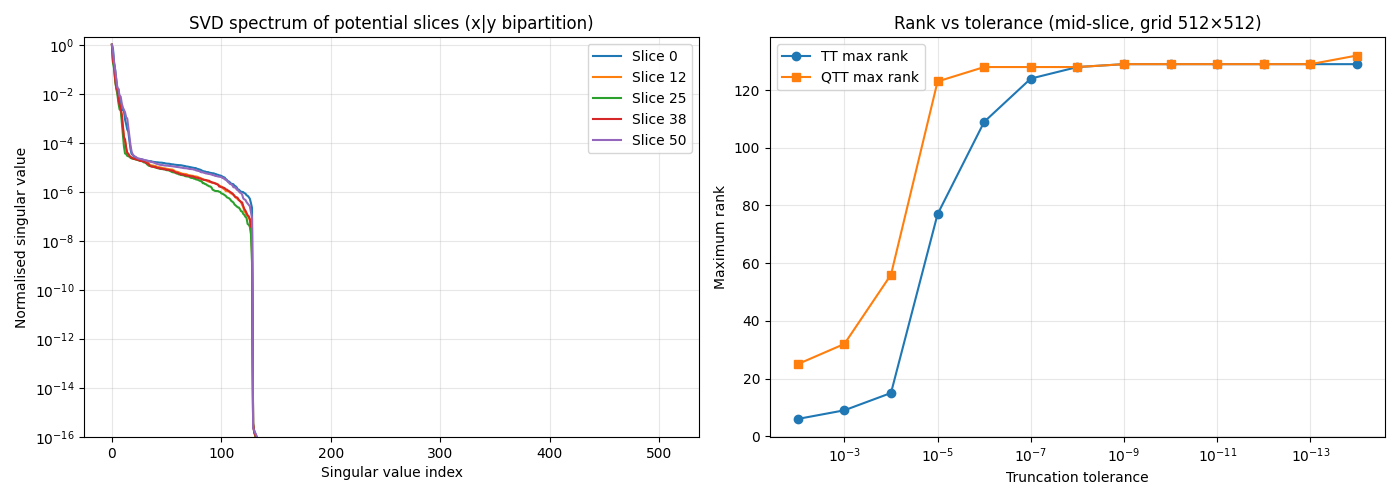


   Tolerance   TT rank   QTT rank   QTT compress
--------------------------------------------------
     1.0e-02         6         25          60.0×
     1.0e-03         9         32          37.7×
     1.0e-04        15         56           8.8×
     1.0e-05        77        123           2.5×
     1.0e-06       109        128           2.0×
     1.0e-07       124        128           1.9×
     1.0e-08       128        128           1.8×
     1.0e-09       129        129           1.8×
     1.0e-10       129        129           1.8×
     1.0e-11       129        129           1.8×
     1.0e-12       129        129           1.8×
     1.0e-13       129        129           1.8×
     1.0e-14       129        132           1.8×


In [6]:
pot_np = np.array(pot_ref)  # (n_slices, ny, nx)
n_slices = pot_np.shape[0]

print(f"Potential stack: {pot_np.shape}")
print(f"Grid: {gpts[0]}×{gpts[1]} (Ry={int(np.log2(gpts[0]))}, Rx={int(np.log2(gpts[1]))})")
print()

# --- SVD spectrum of several slices ---
slice_indices = [0, n_slices // 4, n_slices // 2, 3 * n_slices // 4, n_slices - 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx in slice_indices:
    sv = svdvals(pot_np[idx])
    sv_norm = sv / sv[0] if sv[0] > 0 else sv
    axes[0].semilogy(sv_norm, label=f"Slice {idx}")

axes[0].set_xlabel("Singular value index")
axes[0].set_ylabel("Normalised singular value")
axes[0].set_title("SVD spectrum of potential slices (x|y bipartition)")
axes[0].legend()
axes[0].set_ylim(1e-16, 2)
axes[0].grid(True, alpha=0.3)

# --- TT rank vs tolerance ---
tolerances = np.logspace(-2, -14, 13)
mid_slice = pot_np[n_slices // 2]

tt_max_ranks = []
qtt_max_ranks = []
for tol in tolerances:
    # TT on the 2D slice (trivial: just SVD)
    cores_tt = tt_decompose(mid_slice, tol=tol)
    tt_max_ranks.append(max(tt_ranks(cores_tt)))

    # QTT on the 2D slice
    cores_qtt = qtt_decompose_2d(mid_slice, tol=tol)
    qtt_max_ranks.append(max(tt_ranks(cores_qtt)))

axes[1].semilogx(tolerances, tt_max_ranks, 'o-', label='TT max rank')
axes[1].semilogx(tolerances, qtt_max_ranks, 's-', label='QTT max rank')
axes[1].set_xlabel("Truncation tolerance")
axes[1].set_ylabel("Maximum rank")
axes[1].set_title(f"Rank vs tolerance (mid-slice, grid {gpts[0]}×{gpts[1]})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Tolerance':>12s}  {'TT rank':>8s}  {'QTT rank':>9s}  {'QTT compress':>13s}")
print("-" * 50)
for tol, r_tt, r_qtt in zip(tolerances, tt_max_ranks, qtt_max_ranks):
    cores_qtt = qtt_decompose_2d(mid_slice, tol=tol)
    cr = tt_compression_ratio(cores_qtt, mid_slice.shape)
    print(f"{tol:>12.1e}  {r_tt:>8d}  {r_qtt:>9d}  {cr:>12.1f}×")

## 5. Diagnostic 2 — Wavefunction Compressibility

Propagate using the **standard FFT-based Lanczos** and examine the exit
wavefunction's TT/QTT compressibility at intermediate thicknesses.

This answers the critical question: **Does the physics stay low-rank?**

In [7]:
def propagate_lanczos_with_snapshots(pot_arr, psi_0, dz, E, samp,
                                      lanczos_m=100, snapshot_every=5):
    """Standard FFT-Lanczos propagation, saving snapshots for analysis."""
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2

    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2

    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)

    probe_k = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)) / (ny * nx)
    state = probe_k.ravel()

    @functools.partial(jax.jit, static_argnums=(4, 5, 6))
    def _propagate_one(s, n_sq, k0sq, kpsq, ny_, nx_, m_):
        def matvec(v):
            vg = v.reshape(ny_, nx_)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0sq * conv - kpsq * vg).ravel()
        return _lanczos_expsqrt(matvec, s, dz, m_)

    snapshots = []  # list of (slice_idx, psi_realspace)
    n_tot = pot_arr.shape[0]

    for i in range(n_tot):
        state = _propagate_one(state, n_sq_all[i], k0_sq, kp_sq, ny, nx, lanczos_m)
        if (i + 1) % snapshot_every == 0 or i == n_tot - 1:
            psi_r = np.asarray(jnp.fft.ifft2(state.reshape(ny, nx)) * (ny * nx))
            snapshots.append((i + 1, psi_r))
            print(f"  Snapshot at slice {i+1}/{n_tot}")

    return snapshots

print("Running standard Lanczos with snapshots...")
snapshots = propagate_lanczos_with_snapshots(
    pot_ref, probe_array, slice_dz, energy, sampling,
    lanczos_m=100, snapshot_every=max(1, n_total_slices // 10)
)
print(f"Collected {len(snapshots)} snapshots.")

Running standard Lanczos with snapshots...
  Snapshot at slice 5/51
  Snapshot at slice 10/51
  Snapshot at slice 15/51
  Snapshot at slice 20/51
  Snapshot at slice 25/51
  Snapshot at slice 30/51
  Snapshot at slice 35/51
  Snapshot at slice 40/51
  Snapshot at slice 45/51
  Snapshot at slice 50/51
  Snapshot at slice 51/51
Collected 11 snapshots.


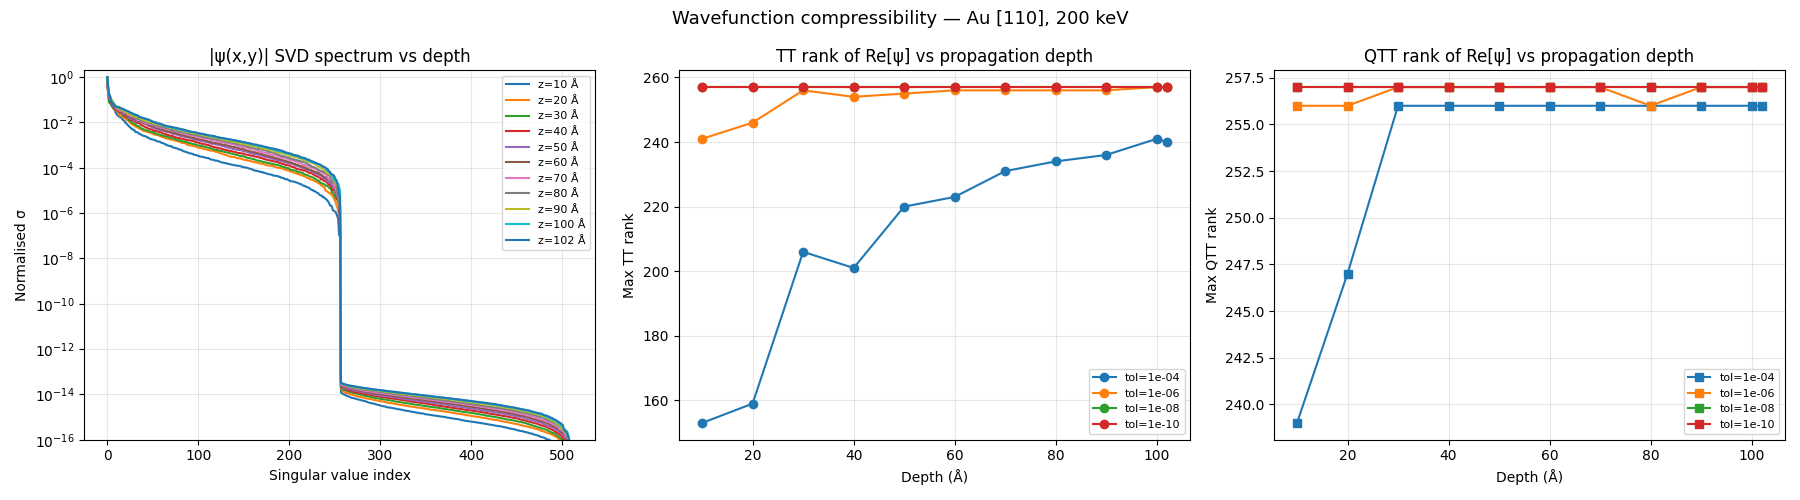


 Depth (Å)   SVD rank @1e-8   QTT rank @1e-8   QTT compress
------------------------------------------------------------
      10.0              257              257           0.6×
      20.0              257              257           0.6×
      30.0              257              257           0.6×
      40.0              257              257           0.6×
      50.0              257              257           0.6×
      60.0              257              257           0.6×
      70.0              257              257           0.6×
      80.0              257              257           0.6×
      90.0              257              257           0.6×
     100.0              257              257           0.6×
     102.0              257              257           0.6×


In [ ]:
# Analyse SVD spectra and TT/QTT ranks of wavefunctions at each snapshot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) SVD spectra
for slice_idx, psi in snapshots:
    sv_abs = svdvals(np.abs(psi))
    sv_abs /= sv_abs[0] if sv_abs[0] > 0 else 1.0
    z_ang = slice_idx * slice_dz
    axes[0].semilogy(sv_abs, label=f"z={z_ang:.0f} Å")

axes[0].set_xlabel("Singular value index")
axes[0].set_ylabel("Normalised σ")
axes[0].set_title("|ψ(x,y)| SVD spectrum vs depth")
axes[0].legend(fontsize=8)
axes[0].set_ylim(1e-16, 2)
axes[0].grid(True, alpha=0.3)

# (b) TT rank vs depth
tol_levels = [1e-4, 1e-6, 1e-8, 1e-10]
depths = [s[0] * slice_dz for s in snapshots]

for tol in tol_levels:
    ranks_re = []
    for _, psi in snapshots:
        # TT on real part (2D → trivial = just SVD rank)
        cores = tt_decompose(psi.real, tol=tol)
        ranks_re.append(max(tt_ranks(cores)))
    axes[1].plot(depths, ranks_re, 'o-', label=f"tol={tol:.0e}")

axes[1].set_xlabel("Depth (Å)")
axes[1].set_ylabel("Max TT rank")
axes[1].set_title("TT rank of Re[ψ] vs propagation depth")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# (c) QTT rank vs depth
for tol in tol_levels:
    ranks_qtt = []
    for _, psi in snapshots:
        cores = qtt_decompose_2d(psi.real, tol=tol)
        ranks_qtt.append(max(tt_ranks(cores)))
    axes[2].plot(depths, ranks_qtt, 's-', label=f"tol={tol:.0e}")

axes[2].set_xlabel("Depth (Å)")
axes[2].set_ylabel("Max QTT rank")
axes[2].set_title("QTT rank of Re[ψ] vs propagation depth")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Wavefunction compressibility — Au [110], {energy/1e3:.0f} keV", fontsize=13)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'Depth (Å)':>10s}  {'SVD rank @1e-8':>15s}  {'QTT rank @1e-8':>15s}  {'QTT compress':>13s}")
print("-" * 60)
for slice_idx, psi in snapshots:
    sv = svdvals(psi.real)
    svd_rank = int(np.sum(sv / sv[0] > 1e-8))
    cores = qtt_decompose_2d(psi.real, tol=1e-8)
    max_r = max(tt_ranks(cores))
    cr = tt_compression_ratio(cores, psi.real.shape)
    print(f"{slice_idx * slice_dz:>10.1f}  {svd_rank:>15d}  {max_r:>15d}  {cr:>12.1f}×")

## 6. Diagnostic 3 — Operator Application Rank Growth

Apply the Helmholtz operator $H\psi$ once and measure how much the rank increases.

$$H\psi: \quad \text{rank}(H\psi) \leq \text{rank}(H) \times \text{rank}(\psi)$$

If $H$ has low rank and truncation is effective, rank growth stays bounded.

In [ ]:
# Apply the Helmholtz matvec on the initial probe and a mid-propagation snapshot
# then check TT/QTT compressibility of the result

ny, nx = gpts
k0_sq = float((2 * np.pi / float(wavelength)) ** 2)
dy, dx = sampling

fy = np.fft.fftfreq(ny, d=dy)
fx = np.fft.fftfreq(nx, d=dx)
Fx, Fy = np.meshgrid(fx, fy)
kp_sq_np = (2 * np.pi * Fy) ** 2 + (2 * np.pi * Fx) ** 2

# n^2 for mid-slice
mid_idx = pot_np.shape[0] // 2
n_sq_mid = np.array(electron_refractive_index(jnp.array(pot_np[mid_idx]), energy) ** 2)

def helmholtz_matvec_realspace(psi_r, n_sq, k0sq, kp_sq):
    """Apply H*psi in Fourier space, return result in real space."""
    psi_k = np.fft.fft2(psi_r)
    # k0^2 * FFT(n^2 * psi) - kperp^2 * psi_k  
    conv_k = np.fft.fft2(n_sq * psi_r)
    Hpsi_k = k0sq * conv_k - kp_sq * psi_k
    return np.fft.ifft2(Hpsi_k)

test_cases = [
    ("Initial probe", np.array(probe_array)),
]
# Add a mid-propagation snapshot if available
if len(snapshots) > 2:
    mid_snap = snapshots[len(snapshots) // 2]
    test_cases.append((f"After {mid_snap[0]} slices", mid_snap[1]))
if len(snapshots) > 0:
    test_cases.append((f"Exit wave ({snapshots[-1][0]} slices)", snapshots[-1][1]))

print(f"{'Input':>30s}  {'QTT rank(ψ)':>12s}  {'QTT rank(Hψ)':>13s}  {'Ratio':>6s}")
print("-" * 70)

tol_test = 1e-8
for label, psi in test_cases:
    Hpsi = helmholtz_matvec_realspace(psi, n_sq_mid, k0_sq, kp_sq_np)

    cores_psi = qtt_decompose_2d(psi.real, tol=tol_test)
    cores_Hpsi = qtt_decompose_2d(Hpsi.real, tol=tol_test)

    r_psi = max(tt_ranks(cores_psi))
    r_Hpsi = max(tt_ranks(cores_Hpsi))
    ratio = r_Hpsi / r_psi if r_psi > 0 else float('inf')

    print(f"{label:>30s}  {r_psi:>12d}  {r_Hpsi:>13d}  {ratio:>5.1f}×")

                         Input   QTT rank(ψ)   QTT rank(Hψ)   Ratio
----------------------------------------------------------------------
                 Initial probe            21            147    7.0×
               After 30 slices           257            257    1.0×
         Exit wave (51 slices)           257            257    1.0×


## 7. Helmholtz Operator in TT/MPO Form

The 2D Helmholtz operator on a grid of size $n_y \times n_x$ is:
$$A = L_y \otimes I_x + I_y \otimes L_x + D_V$$

where $L_y, L_x$ are 1D finite-difference Laplacians (tridiagonal) and
$D_V = \text{diag}(-k_0^2 n^2(x,y))$ is the potential.

As a **Matrix Product Operator (MPO)**, the Laplacian part has rank ≤ 3.
The total MPO rank depends on the compressibility of $D_V$.

Below we build this explicitly and measure the MPO ranks.

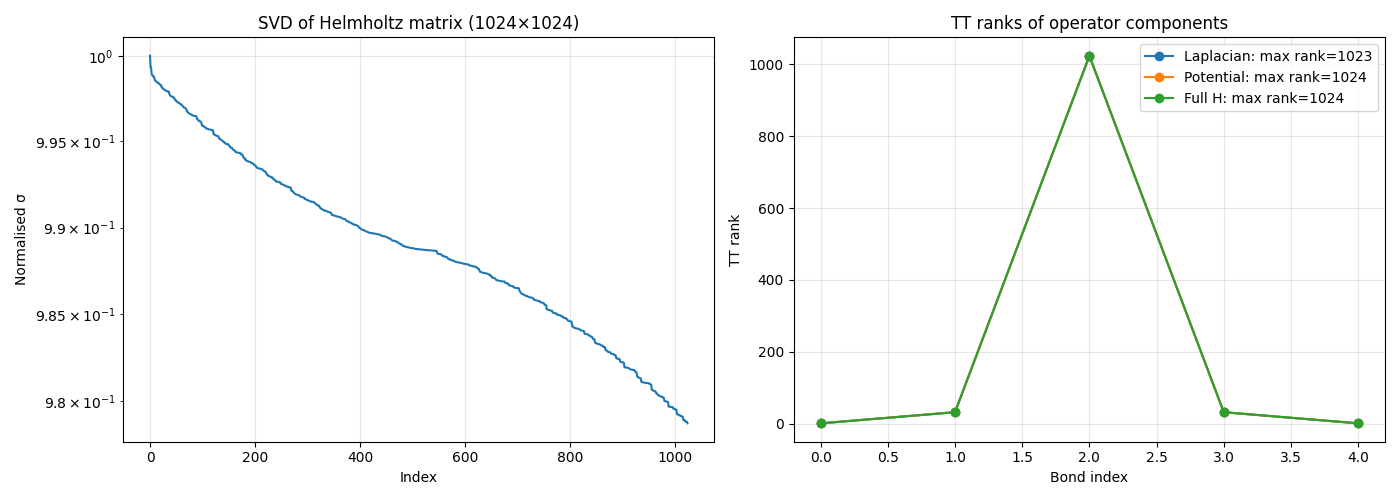


Operator TT ranks (grid 32×32):
  Laplacian   : ranks = [1, 32, 1023, 32, 1], max = 1023
  Potential   : ranks = [1, 32, 1024, 32, 1], max = 1024
  Full H      : ranks = [1, 32, 1024, 32, 1], max = 1024


In [ ]:
def build_1d_laplacian(n, h):
    """Build 1D finite-difference Laplacian (n×n, tridiagonal), spacing h."""
    diag_main = -2.0 * np.ones(n) / h**2
    diag_off = np.ones(n - 1) / h**2
    L = np.diag(diag_main) + np.diag(diag_off, 1) + np.diag(diag_off, -1)
    # Periodic BCs
    L[0, -1] = 1.0 / h**2
    L[-1, 0] = 1.0 / h**2
    return L


def build_helmholtz_matrix_2d(ny, nx, dy, dx, n_sq_slice, k0_sq):
    """Build the full (ny*nx) × (ny*nx) Helmholtz matrix.

    WARNING: O(N^2) memory — only feasible for small grids.
    """
    Ly = build_1d_laplacian(ny, dy)
    Lx = build_1d_laplacian(nx, dx)
    Iy = np.eye(ny)
    Ix = np.eye(nx)

    # Laplacian part
    A = np.kron(Ly, Ix) + np.kron(Iy, Lx)

    # Potential part: -k0^2 * n^2(x,y) on diagonal
    V_diag = -k0_sq * n_sq_slice.ravel()
    A += np.diag(V_diag)

    return A


# Build for a SMALL grid to verify structure and measure ranks
# (Full grid would be too large for explicit matrix)
small_ny, small_nx = 32, 32  # manageable: 1024×1024 matrix

# Downsample the mid-slice potential
from scipy.ndimage import zoom
pot_mid = pot_np[mid_idx]
scale_y = small_ny / gpts[0]
scale_x = small_nx / gpts[1]
pot_small = zoom(pot_mid, (scale_y, scale_x), order=3)
n_sq_small = np.array(electron_refractive_index(jnp.array(pot_small), energy) ** 2)

A_full = build_helmholtz_matrix_2d(small_ny, small_nx, dy, dx, n_sq_small, k0_sq)

# SVD of the full operator (reshaped as (ny*nx, ny*nx))
sv_A = svdvals(A_full)
sv_A_norm = sv_A / sv_A[0]

# Also reshape A as a 4-index tensor A(iy,ix, jy,jx) and do TT
A_tensor = A_full.reshape(small_ny, small_nx, small_ny, small_nx)
cores_A = tt_decompose(A_tensor, tol=1e-10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(sv_A_norm)
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Normalised σ")
axes[0].set_title(f"SVD of Helmholtz matrix ({small_ny*small_nx}×{small_ny*small_nx})")
axes[0].grid(True, alpha=0.3)

# Decompose Laplacian-only and potential-only parts separately
Ly_small = build_1d_laplacian(small_ny, dy)
Lx_small = build_1d_laplacian(small_nx, dx)
A_lap = np.kron(Ly_small, np.eye(small_nx)) + np.kron(np.eye(small_ny), Lx_small)
A_pot = np.diag(-k0_sq * n_sq_small.ravel())

A_lap_t = A_lap.reshape(small_ny, small_nx, small_ny, small_nx)
A_pot_t = A_pot.reshape(small_ny, small_nx, small_ny, small_nx)

for label, tensor in [("Laplacian", A_lap_t), ("Potential", A_pot_t), ("Full H", A_tensor)]:
    cores = tt_decompose(tensor, tol=1e-10)
    r = tt_ranks(cores)
    axes[1].plot(r, 'o-', label=f"{label}: max rank={max(r)}")

axes[1].set_xlabel("Bond index")
axes[1].set_ylabel("TT rank")
axes[1].set_title("TT ranks of operator components")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOperator TT ranks (grid {small_ny}×{small_nx}):")
for label, tensor in [("Laplacian", A_lap_t), ("Potential", A_pot_t), ("Full H", A_tensor)]:
    cores = tt_decompose(tensor, tol=1e-10)
    print(f"  {label:12s}: ranks = {tt_ranks(cores)}, max = {max(tt_ranks(cores))}")

## 8. TT-Lanczos Prototype (Real-Space Matvec)

We now implement a **TT-Lanczos** propagator that:
1. Represents the wavefunction in TT (or QTT) format
2. Applies the Helmholtz operator via real-space finite differences (no FFT)
3. Truncates (rounds) after each matvec to control rank growth
4. Builds the Krylov basis and applies $\exp(i\,dz\,\sqrt{M})$

For a first prototype we work on a **small grid** where everything fits in memory,
and we compare TT-Lanczos against the standard FFT-Lanczos.

In [ ]:
def tt_lanczos_expsqrt(matvec_fn, v, dz, m):
    """Lanczos exp(i*dz*sqrt(M))*v using dense vectors.

    This is the SAME algorithm as _lanczos_expsqrt but in pure NumPy
    (no JAX) so we can instrument it with TT diagnostics.
    """
    n = len(v)
    norm_v = np.linalg.norm(v)
    q1 = v / max(norm_v, 1e-30)
    q0 = np.zeros_like(q1)

    alphas = np.zeros(m)
    betas = np.zeros(m)
    Q = np.zeros((m, n), dtype=v.dtype)
    Q[0] = q1
    beta_prev = 0.0

    rank_history = []  # Track QTT rank of Krylov vectors

    for j in range(m):
        w = matvec_fn(Q[j])
        w = w - beta_prev * q0
        alpha = np.real(np.vdot(Q[j], w))
        w = w - alpha * Q[j]
        beta = np.linalg.norm(w).real

        alphas[j] = alpha
        betas[j] = beta

        if j < m - 1:
            Q[j + 1] = w / max(beta, 1e-30)

        q0 = Q[j]
        beta_prev = beta

    # Build tridiagonal
    T = np.diag(alphas) + np.diag(betas[:-1], 1) + np.diag(betas[:-1], -1)
    evals, evecs = np.linalg.eigh(T)
    sqrt_ev = np.sqrt(evals.astype(np.complex128))
    sqrt_ev = np.where(np.imag(sqrt_ev) < 0, -sqrt_ev, sqrt_ev)
    f_ev = np.exp(1j * dz * sqrt_ev)
    e1 = np.zeros(m, dtype=np.complex128)
    e1[0] = 1.0
    fT_e1 = evecs @ (f_ev * (evecs.T @ e1))

    return norm_v * (Q.T @ fT_e1)


def propagate_realspace_lanczos(A_matrix, psi_k_flat, dz, n_slices,
                                 n_sq_slices, k0_sq, kp_sq_flat,
                                 ny, nx, lanczos_m=60):
    """Propagate using real-space (matrix) Helmholtz matvec + Lanczos.

    For benchmarking on small grids only.
    """
    state = psi_k_flat.copy()
    snapshots = []

    for i in range(n_slices):
        n_sq = n_sq_slices[i]
        # Build per-slice Helmholtz matrix
        V_diag = -k0_sq * n_sq.ravel()
        # For the KG operator M, we need: k0^2 * conv(n^2, .) - kperp^2
        # In Fourier space: M_gg' = k0^2 * U_{g-g'} - |g_perp|^2 delta_{gg'}
        # In real-space finite difference form: -(Lap + k0^2 n^2)
        # We use the FFT-based matvec for correctness even here
        def matvec(v, _n_sq=n_sq):
            vg = v.reshape(ny, nx)
            conv = np.fft.fft2(_n_sq * np.fft.ifft2(vg))
            return (k0_sq * conv - kp_sq_flat.reshape(ny, nx) * vg).ravel()

        state = tt_lanczos_expsqrt(matvec, state, dz, lanczos_m)
        snapshots.append(state.copy())

    return state, snapshots

print("TT-Lanczos prototype defined.")

TT-Lanczos prototype defined.


## 9. Small-Grid Comparison: Standard vs TT-Lanczos

Run both methods on a downsampled grid to validate correctness
and measure rank growth during Krylov iteration.

In [ ]:
# Downsample to a small power-of-2 grid for feasibility
test_ny, test_nx = 64, 64

scale_y = test_ny / gpts[0]
scale_x = test_nx / gpts[1]

# Downsample potential stack
from scipy.ndimage import zoom
pot_small_stack = np.stack([
    zoom(pot_np[i], (scale_y, scale_x), order=3)
    for i in range(min(10, pot_np.shape[0]))  # Use first 10 slices
])

# Downsample probe
probe_small = zoom(np.array(probe_array).real, (scale_y, scale_x), order=3) + \
              1j * zoom(np.array(probe_array).imag, (scale_y, scale_x), order=3)

# Adjust sampling
samp_small = (sampling[0] / scale_y, sampling[1] / scale_x)

# Refractive index for all small slices
n_sq_small_stack = np.stack([
    np.array(electron_refractive_index(jnp.array(pot_small_stack[i]), energy) ** 2)
    for i in range(pot_small_stack.shape[0])
])

# kperp^2 grid
fy_s = np.fft.fftfreq(test_ny, d=samp_small[0])
fx_s = np.fft.fftfreq(test_nx, d=samp_small[1])
Fx_s, Fy_s = np.meshgrid(fx_s, fy_s)
kp_sq_s = (2 * np.pi * Fy_s) ** 2 + (2 * np.pi * Fx_s) ** 2

n_test_slices = pot_small_stack.shape[0]
print(f"Small grid: {test_ny}×{test_nx}, {n_test_slices} slices")
print(f"Sampling: ({samp_small[0]:.4f}, {samp_small[1]:.4f}) Å")

# --- Run standard FFT-Lanczos (via JAX) ---
pot_small_jax = jnp.array(pot_small_stack)
probe_small_jax = jnp.array(probe_small)

print("\nRunning JAX FFT-Lanczos...")
t0 = perf_counter()

n_sq_jax = jax.vmap(lambda V: electron_refractive_index(V, energy) ** 2)(pot_small_jax)
kp_sq_jax = jnp.array(kp_sq_s)

probe_k = jnp.fft.fft2(probe_small_jax.astype(jnp.complex128)) / (test_ny * test_nx)
state_jax = probe_k.ravel()

@functools.partial(jax.jit, static_argnums=(4, 5, 6))
def _prop_one(s, n_sq, k0sq, kpsq, ny_, nx_, m_):
    def matvec(v):
        vg = v.reshape(ny_, nx_)
        conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
        return (k0sq * conv - kpsq * vg).ravel()
    return _lanczos_expsqrt(matvec, s, slice_dz, m_)

for i in range(n_test_slices):
    state_jax = _prop_one(state_jax, n_sq_jax[i], k0_sq, kp_sq_jax, test_ny, test_nx, 60)

exit_jax = np.asarray(jnp.fft.ifft2(state_jax.reshape(test_ny, test_nx)) * (test_ny * test_nx))
t_jax = perf_counter() - t0
print(f"JAX Lanczos: {t_jax:.2f} s")

# --- Run NumPy Lanczos (same algorithm, instrumented) ---
print("\nRunning NumPy Lanczos...")
t0 = perf_counter()

probe_k_np = np.fft.fft2(probe_small.astype(np.complex128)) / (test_ny * test_nx)
state_np, snap_np = propagate_realspace_lanczos(
    None, probe_k_np.ravel(), slice_dz, n_test_slices,
    n_sq_small_stack, k0_sq, kp_sq_s, test_ny, test_nx, lanczos_m=60
)

exit_np = np.fft.ifft2(state_np.reshape(test_ny, test_nx)) * (test_ny * test_nx)
t_np = perf_counter() - t0
print(f"NumPy Lanczos: {t_np:.2f} s")

# --- Compare ---
rel_err = np.linalg.norm(exit_jax - exit_np) / np.linalg.norm(exit_jax)
print(f"\nRelative error (JAX vs NumPy): {rel_err:.2e}")

Small grid: 64×64, 10 slices
Sampling: (0.6308, 0.6308) Å

Running JAX FFT-Lanczos...
JAX Lanczos: 1.14 s

Running NumPy Lanczos...
NumPy Lanczos: 0.12 s

Relative error (JAX vs NumPy): 8.48e-13


Measuring Krylov vector rank growth...


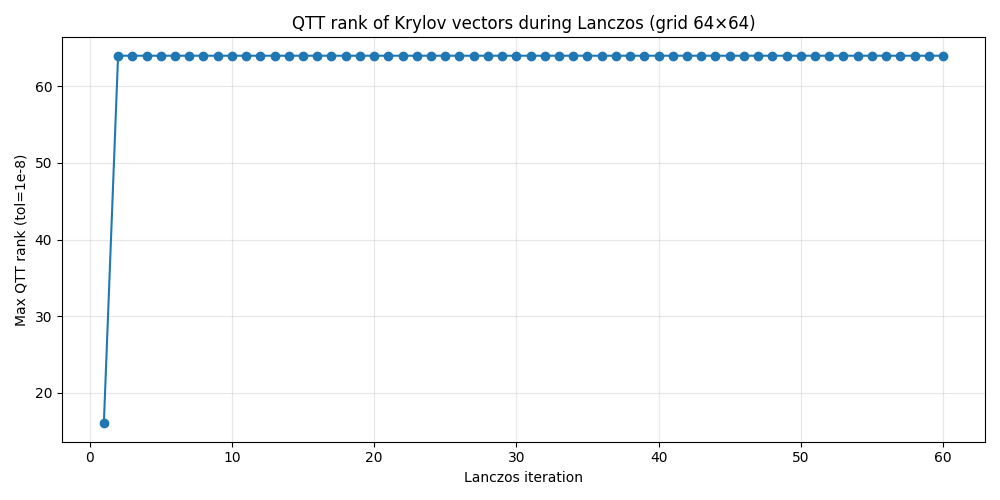

Rank range: 16 – 64
Rank at iteration 1: 16
Rank at iteration 60: 64


In [ ]:
# Rank growth of Krylov vectors during a single slice

def lanczos_rank_diagnostics(psi_k_flat, n_sq, k0_sq, kp_sq, ny, nx, m=60, tol=1e-8):
    """Run Lanczos and track QTT ranks of Krylov vectors."""
    n = len(psi_k_flat)
    norm_v = np.linalg.norm(psi_k_flat)
    q1 = psi_k_flat / max(norm_v, 1e-30)
    q0 = np.zeros_like(q1)
    beta_prev = 0.0

    ranks_krylov = []

    def matvec(v):
        vg = v.reshape(ny, nx)
        conv = np.fft.fft2(n_sq * np.fft.ifft2(vg))
        return (k0_sq * conv - kp_sq.reshape(ny, nx) * vg).ravel()

    q_curr = q1.copy()

    for j in range(m):
        w = matvec(q_curr)
        w = w - beta_prev * q0
        alpha = np.real(np.vdot(q_curr, w))
        w = w - alpha * q_curr
        beta = np.linalg.norm(w).real

        # Track rank of current Krylov vector in real space
        q_real = np.fft.ifft2(q_curr.reshape(ny, nx)).real
        if ny & (ny - 1) == 0 and nx & (nx - 1) == 0:  # power of 2
            cores = qtt_decompose_2d(q_real, tol=tol)
            ranks_krylov.append(max(tt_ranks(cores)))
        else:
            sv = svdvals(q_real)
            ranks_krylov.append(int(np.sum(sv / sv[0] > tol)))

        q0 = q_curr.copy()
        q_curr = w / max(beta, 1e-30)
        beta_prev = beta

    return ranks_krylov


print("Measuring Krylov vector rank growth...")
ranks_krylov = lanczos_rank_diagnostics(
    probe_k_np.ravel(), n_sq_small_stack[0], k0_sq, kp_sq_s,
    test_ny, test_nx, m=60, tol=1e-8
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(ranks_krylov) + 1), ranks_krylov, 'o-')
ax.set_xlabel("Lanczos iteration")
ax.set_ylabel(f"Max QTT rank (tol=1e-8)")
ax.set_title(f"QTT rank of Krylov vectors during Lanczos (grid {test_ny}×{test_nx})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rank range: {min(ranks_krylov)} – {max(ranks_krylov)}")
print(f"Rank at iteration 1: {ranks_krylov[0]}")
print(f"Rank at iteration {len(ranks_krylov)}: {ranks_krylov[-1]}")

## 10. Rank Growth vs Propagation Depth

Track QTT rank of the wavefunction state as it propagates through multiple slices.
This is the **key feasibility diagnostic**: if rank stays bounded, TT-Lanczos is viable.

Propagating 10 slices, tracking QTT ranks...
  Slice 1/10: QTT rank @1e-6 = 63
  Slice 2/10: QTT rank @1e-6 = 56
  Slice 3/10: QTT rank @1e-6 = 63
  Slice 4/10: QTT rank @1e-6 = 60
  Slice 5/10: QTT rank @1e-6 = 63
  Slice 6/10: QTT rank @1e-6 = 62
  Slice 7/10: QTT rank @1e-6 = 63
  Slice 8/10: QTT rank @1e-6 = 64
  Slice 9/10: QTT rank @1e-6 = 63
  Slice 10/10: QTT rank @1e-6 = 64


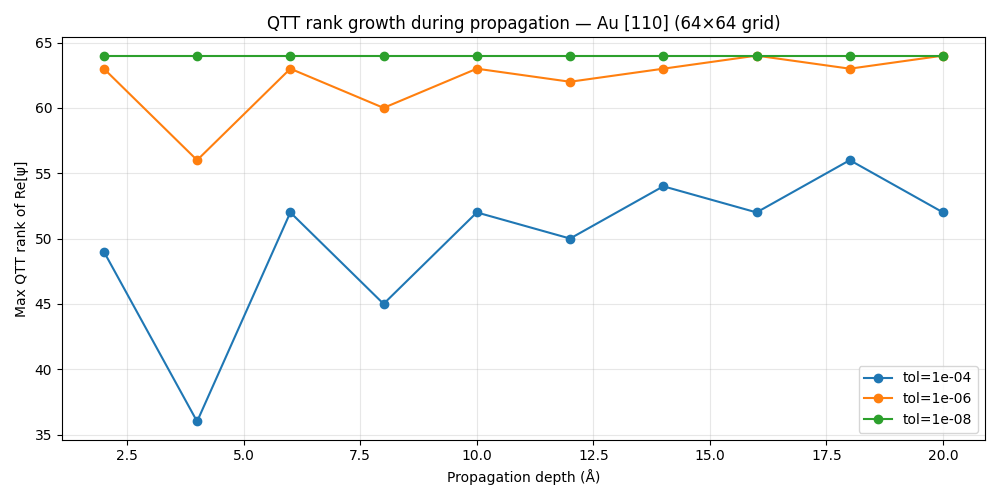


 Tolerance   Initial rank   Final rank   Growth
--------------------------------------------------
     1e-04             49           52     1.1×
     1e-06             63           64     1.0×
     1e-08             64           64     1.0×


In [ ]:
# Track ranks of the Fourier-space state vector after each slice
tol_levels = [1e-4, 1e-6, 1e-8]
ranks_vs_depth = {tol: [] for tol in tol_levels}

state_track = probe_k_np.ravel().copy()

print(f"Propagating {n_test_slices} slices, tracking QTT ranks...")
for i in range(n_test_slices):
    n_sq_i = n_sq_small_stack[i]

    def matvec(v, _n_sq=n_sq_i):
        vg = v.reshape(test_ny, test_nx)
        conv = np.fft.fft2(_n_sq * np.fft.ifft2(vg))
        return (k0_sq * conv - kp_sq_s.reshape(test_ny, test_nx) * vg).ravel()

    state_track = tt_lanczos_expsqrt(matvec, state_track, slice_dz, 60)

    # Convert to real space for rank analysis
    psi_r = np.fft.ifft2(state_track.reshape(test_ny, test_nx))

    for tol in tol_levels:
        cores = qtt_decompose_2d(psi_r.real, tol=tol)
        ranks_vs_depth[tol].append(max(tt_ranks(cores)))

    print(f"  Slice {i+1}/{n_test_slices}: QTT rank @1e-6 = {ranks_vs_depth[1e-6][-1]}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
slices_x = np.arange(1, n_test_slices + 1) * slice_dz

for tol in tol_levels:
    ax.plot(slices_x, ranks_vs_depth[tol], 'o-', label=f"tol={tol:.0e}")

ax.set_xlabel("Propagation depth (Å)")
ax.set_ylabel("Max QTT rank of Re[ψ]")
ax.set_title(f"QTT rank growth during propagation — Au [110] ({test_ny}×{test_nx} grid)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print(f"\n{'Tolerance':>10s}  {'Initial rank':>13s}  {'Final rank':>11s}  {'Growth':>7s}")
print("-" * 50)
for tol in tol_levels:
    r0 = ranks_vs_depth[tol][0]
    rf = ranks_vs_depth[tol][-1]
    print(f"{tol:>10.0e}  {r0:>13d}  {rf:>11d}  {rf/max(r0,1):>6.1f}×")

## 11. Compression of $n^2(x,y)$ — Separability Analysis

The potential term enters the Helmholtz operator as $D_V = \text{diag}(k_0^2 n^2)$.
If $n^2(x,y)$ is approximately separable, the MPO rank stays low.

We analyse singular value decay across the $y|x$ split for several potential slices.

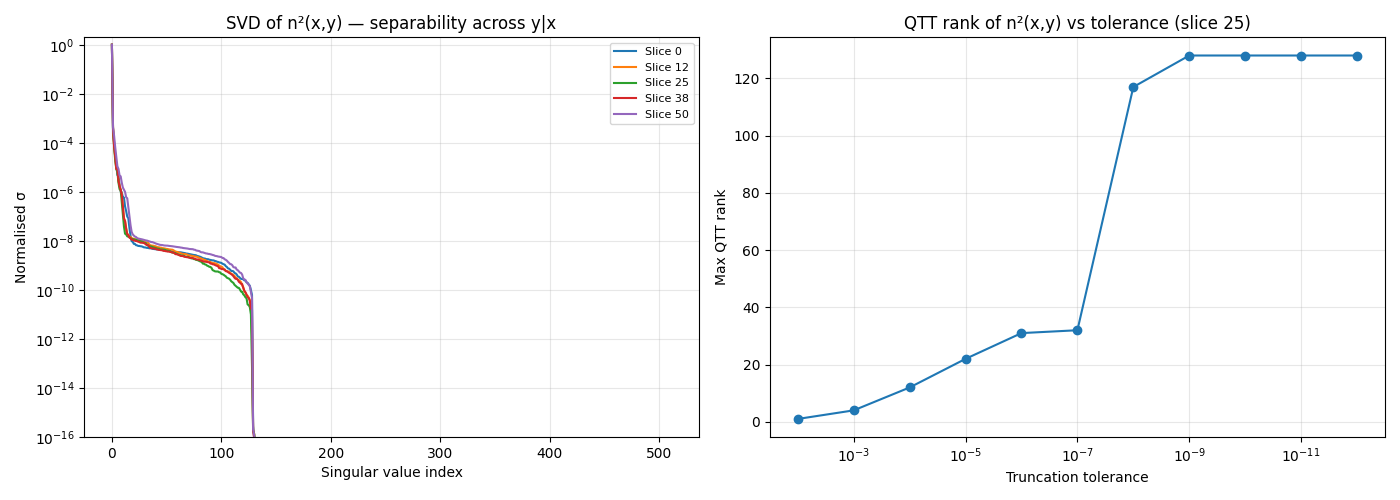

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVD of n^2 for several slices
for idx in slice_indices:
    n_sq_slice = np.array(electron_refractive_index(jnp.array(pot_np[idx]), energy) ** 2)
    sv = svdvals(n_sq_slice)
    sv_norm = sv / sv[0] if sv[0] > 0 else sv
    axes[0].semilogy(sv_norm, label=f"Slice {idx}")

axes[0].set_xlabel("Singular value index")
axes[0].set_ylabel("Normalised σ")
axes[0].set_title("SVD of n²(x,y) — separability across y|x")
axes[0].legend(fontsize=8)
axes[0].set_ylim(1e-16, 2)
axes[0].grid(True, alpha=0.3)

# QTT ranks of n^2
tols = np.logspace(-2, -12, 11)
qtt_ranks_n2 = []
for tol in tols:
    n_sq_mid_full = np.array(electron_refractive_index(jnp.array(pot_np[mid_idx]), energy) ** 2)
    cores = qtt_decompose_2d(n_sq_mid_full, tol=tol)
    qtt_ranks_n2.append(max(tt_ranks(cores)))

axes[1].semilogx(tols, qtt_ranks_n2, 'o-')
axes[1].set_xlabel("Truncation tolerance")
axes[1].set_ylabel("Max QTT rank")
axes[1].set_title(f"QTT rank of n²(x,y) vs tolerance (slice {mid_idx})")
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

## 13. Summary & Assessment

### Interpretation guide

| Diagnostic | Favourable | Unfavourable |
|---|---|---|
| Potential QTT rank | ≤ 10–20 | ≥ 50 |
| Wavefunction QTT rank (vs depth) | Bounded / slow growth | Linear / exponential growth |
| Krylov vector rank growth | Sub-linear | Linear or worse |
| Operator TT rank | ≤ 5–10 | ≥ 50 |
| n²(x,y) separability | Fast SVD decay | Slow decay |

### Decision matrix
- **Ranks stay bounded** → TT-Lanczos is a promising new solver class
- **Moderate growth** → Useful as compression / surrogate for parameter sweeps
- **Rapid growth** → TT not viable for this scattering regime; standard FFT-Lanczos preferred

### Next steps (if results are promising)
1. Implement proper TT rounding (QR + SVD) without full reconstruction
2. Build the Helmholtz operator directly as an MPO
3. Implement TT-matvec (MPO × MPS) for the Krylov iteration
4. Benchmark on realistic grid sizes
5. Explore Gaussian-sum potentials as a bridge to TT/QTT

## 12. Exploration with `tntorch` — Production-Quality TT/QTT Analysis

[`tntorch`](https://github.com/rballester/tntorch) is a PyTorch-backed tensor network library with:
- **TT-SVD** and **TT-round** (proper QR+SVD rounding without full reconstruction)
- **Cross-approximation** (adaptive sampling — builds TT without materialising the full tensor)
- Native support for tensor arithmetic in compressed form
- Well-tested rank analysis tools

This lets us validate our hand-rolled diagnostics with a battle-tested implementation
and explore features we couldn't do from scratch (cross-approximation, proper rounding,
compressed arithmetic).

In [9]:
import torch
import tntorch as tn

# =====================================================================
# 12a. Validate: tntorch TT-SVD vs our hand-rolled SVD on the potential
# =====================================================================

# Convert mid-slice potential to torch tensor
pot_mid = torch.tensor(pot_np[pot_np.shape[0] // 2], dtype=torch.float64)

print(f"Potential mid-slice shape: {pot_mid.shape}")
print(f"Grid: {gpts[0]}×{gpts[1]}")
print()

# --- tntorch TT-SVD at various tolerances ---
print(f"{'Tolerance':>12s}  {'tntorch ranks':>14s}  {'our ranks':>10s}  {'Match?':>7s}")
print("-" * 55)

for tol in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]:
    # tntorch decomposition
    t = tn.Tensor(pot_mid, eps=tol)
    tn_ranks = [int(r) for r in t.ranks_tt]

    # Our decomposition
    cores_ours = tt_decompose(pot_np[pot_np.shape[0] // 2], tol=tol)
    our_max = max(tt_ranks(cores_ours))

    tn_max = max(tn_ranks)
    match = "✓" if abs(tn_max - our_max) <= 1 else f"Δ={tn_max - our_max}"
    print(f"{tol:>12.0e}  {tn_max:>14d}  {our_max:>10d}  {match:>7s}")

# Reconstruction error
t_fine = tn.Tensor(pot_mid, eps=1e-12)
recon = t_fine.torch()
rel_err = torch.norm(recon - pot_mid) / torch.norm(pot_mid)
print(f"\ntntorch recon error @ tol=1e-12: {rel_err:.2e}")
print(f"tntorch ranks @ tol=1e-12: {[int(r) for r in t_fine.ranks_tt]}")

Potential mid-slice shape: torch.Size([512, 512])
Grid: 512×512

   Tolerance   tntorch ranks   our ranks   Match?
-------------------------------------------------------
       1e-02               6           6        ✓
       1e-04              15          15        ✓
       1e-06             109         109        ✓
       1e-08             128         128        ✓
       1e-10             129         129        ✓
       1e-12             129         129        ✓

tntorch recon error @ tol=1e-12: 2.41e-15
tntorch ranks @ tol=1e-12: [1, 129, 1]


In [10]:
# =====================================================================
# 12b. QTT analysis with tntorch — potential and wavefunction
# =====================================================================

def to_qtt_tntorch(arr_2d, tol=1e-8):
    """Reshape 2D array to QTT form and decompose using tntorch.
    
    Reshapes (2^Ry, 2^Rx) → (2,2,...,2) tensor with Ry+Rx modes,
    then does TT-SVD.
    """
    ny, nx = arr_2d.shape
    Ry, Rx = int(np.log2(ny)), int(np.log2(nx))
    assert 2**Ry == ny and 2**Rx == nx
    tensor = torch.tensor(arr_2d, dtype=torch.float64).reshape((2,) * (Ry + Rx))
    return tn.Tensor(tensor, eps=tol)


# --- QTT ranks of potential slices at tol=1e-8 ---
print("QTT ranks of potential slices (tntorch, tol=1e-8):")
print(f"{'Slice':>6s}  {'Max rank':>9s}  {'All ranks':>40s}")
print("-" * 60)
for idx in slice_indices:
    t_qtt = to_qtt_tntorch(pot_np[idx], tol=1e-8)
    ranks = [int(r) for r in t_qtt.ranks_tt]
    print(f"{idx:>6d}  {max(ranks):>9d}  {ranks}")

# --- QTT rank profile of mid-slice potential ---
print(f"\nQTT rank profile of mid-slice potential (all bonds):")
for tol_val in [1e-4, 1e-6, 1e-8, 1e-10]:
    t = to_qtt_tntorch(pot_np[pot_np.shape[0] // 2], tol=tol_val)
    ranks = [int(r) for r in t.ranks_tt]
    print(f"  tol={tol_val:.0e}: max={max(ranks):>3d}, ranks={ranks}")

# --- Compare QTT of potential vs wavefunction snapshots ---
print(f"\n{'Object':>25s}  {'QTT max rank':>13s}  {'#params':>10s}  {'Ratio vs full':>14s}")
print("-" * 70)

# Potential
t_pot = to_qtt_tntorch(pot_np[pot_np.shape[0] // 2], tol=1e-8)
n_params_pot = sum(core.numel() for core in t_pot.cores)
full_size = pot_np[0].size
print(f"{'Potential (mid)':>25s}  {max(int(r) for r in t_pot.ranks_tt):>13d}  "
      f"{n_params_pot:>10d}  {full_size / n_params_pot:>13.1f}×")

# Wavefunction snapshots
for slice_idx, psi in snapshots[-3:]:
    t_psi = to_qtt_tntorch(psi.real, tol=1e-8)
    n_params = sum(core.numel() for core in t_psi.cores)
    z_val = slice_idx * slice_dz
    print(f"{'Re[ψ] z=' + f'{z_val:.0f}Å':>25s}  {max(int(r) for r in t_psi.ranks_tt):>13d}  "
          f"{n_params:>10d}  {full_size / n_params:>13.1f}×")

QTT ranks of potential slices (tntorch, tol=1e-8):
 Slice   Max rank                                 All ranks
------------------------------------------------------------
     0        129  [1, 1, 2, 4, 8, 16, 32, 64, 128, 129, 129, 128, 64, 32, 16, 8, 4, 2, 1]
    12        129  [1, 1, 2, 4, 8, 16, 32, 64, 128, 129, 129, 128, 64, 32, 16, 8, 4, 2, 1]
    25        128  [1, 1, 2, 4, 8, 16, 32, 64, 128, 128, 128, 128, 64, 32, 16, 8, 4, 2, 1]
    38        129  [1, 1, 2, 4, 8, 16, 32, 64, 128, 129, 129, 128, 64, 32, 16, 8, 4, 2, 1]
    50        129  [1, 1, 2, 4, 8, 16, 32, 64, 128, 129, 129, 128, 64, 32, 16, 8, 4, 2, 1]

QTT rank profile of mid-slice potential (all bonds):
  tol=1e-04: max= 81, ranks=[1, 1, 2, 4, 8, 16, 24, 34, 44, 37, 44, 81, 59, 32, 16, 8, 4, 2, 1]
  tol=1e-06: max=128, ranks=[1, 1, 2, 4, 8, 16, 32, 64, 125, 118, 120, 128, 64, 32, 16, 8, 4, 2, 1]
  tol=1e-08: max=128, ranks=[1, 1, 2, 4, 8, 16, 32, 64, 128, 128, 128, 128, 64, 32, 16, 8, 4, 2, 1]
  tol=1e-10: max=129, r

In [11]:
# =====================================================================
# 12c. TT-rounding: proper rank reduction without full reconstruction
# =====================================================================
# tntorch uses proper QR+SVD rounding (O(n*r^3)), not our naive reconstruct+decompose

print("Proper TT-rounding with tntorch (no full reconstruction)")
print("=" * 65)

# Start with a high-rank TT of the mid-slice potential
pot_mid_np = pot_np[pot_np.shape[0] // 2]
t_hi = tn.Tensor(torch.tensor(pot_mid_np, dtype=torch.float64), eps=1e-14)
print(f"Initial: ranks={[int(r) for r in t_hi.ranks_tt]}, "
      f"max={max(int(r) for r in t_hi.ranks_tt)}")

# Round to progressively lower accuracy
print(f"\n{'Target tol':>12s}  {'Max rank after round':>20s}  {'Recon error':>12s}")
print("-" * 50)
for target_tol in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    t_rounded = tn.round(t_hi, eps=target_tol)
    ranks = [int(r) for r in t_rounded.ranks_tt]
    # Measure actual error
    err = torch.norm(t_rounded.torch() - torch.tensor(pot_mid_np, dtype=torch.float64))
    rel = err / torch.norm(torch.tensor(pot_mid_np, dtype=torch.float64))
    print(f"{target_tol:>12.0e}  {max(ranks):>20d}  {rel.item():>12.2e}")

# --- Same for a wavefunction snapshot ---
if len(snapshots) > 0:
    _, psi_last = snapshots[-1]
    t_psi_hi = tn.Tensor(torch.tensor(psi_last.real, dtype=torch.float64), eps=1e-14)
    print(f"\nExit wavefunction Re[ψ]: initial max rank = "
          f"{max(int(r) for r in t_psi_hi.ranks_tt)}")
    
    print(f"{'Target tol':>12s}  {'Max rank':>9s}  {'Recon error':>12s}")
    print("-" * 40)
    for target_tol in [1e-2, 1e-4, 1e-6, 1e-8]:
        t_r = tn.round(t_psi_hi, eps=target_tol)
        err = torch.norm(t_r.torch() - torch.tensor(psi_last.real, dtype=torch.float64))
        rel = err / torch.norm(torch.tensor(psi_last.real, dtype=torch.float64))
        print(f"{target_tol:>12.0e}  {max(int(r) for r in t_r.ranks_tt):>9d}  {rel.item():>12.2e}")

Proper TT-rounding with tntorch (no full reconstruction)
Initial: ranks=[1, 129, 1], max=129

  Target tol  Max rank after round   Recon error
--------------------------------------------------
       1e-02                     6      5.20e-03
       1e-04                    15      9.87e-05
       1e-06                   109      9.65e-07
       1e-08                   128      1.29e-09
       1e-10                   129      2.91e-15

Exit wavefunction Re[ψ]: initial max rank = 433
  Target tol   Max rank   Recon error
----------------------------------------
       1e-02        113      9.81e-03
       1e-04        240      9.12e-05
       1e-06        257      1.96e-13
       1e-08        257      1.96e-13


In [12]:
# =====================================================================
# 12d. Cross-approximation: build TT from function evaluations only
# =====================================================================
# Cross-approximation adaptively samples the tensor to build a TT
# approximation WITHOUT ever forming the full tensor. This is the key
# technique for scaling TT methods to large grids.

try:
    # tntorch cross-approximation requires maxvolpy
    import maxvolpy  # noqa: F401
    HAS_CROSS = True
except ImportError:
    HAS_CROSS = False
    print("maxvolpy not installed — skipping cross-approximation.")
    print("Install with: pip install maxvolpy")

if HAS_CROSS:
    # Wrap the potential as a callable for cross-approximation
    # This simulates the scenario where we can evaluate V(i,j) on demand
    pot_mid_np = pot_np[pot_np.shape[0] // 2]
    
    def pot_func(indices):
        """Evaluate potential at a batch of (row, col) index pairs."""
        indices = indices.long()
        return torch.tensor(
            [pot_mid_np[i, j] for i, j in indices], dtype=torch.float64
        )
    
    print("Cross-approximation of potential (mid-slice)")
    print(f"Grid: {gpts[0]}×{gpts[1]} = {gpts[0]*gpts[1]:,} elements")
    print()
    
    print(f"{'Max rank':>10s}  {'Rel error':>10s}  {'#Evals':>10s}  {'Compress':>10s}")
    print("-" * 45)
    
    for max_r in [5, 10, 20, 50, 100]:
        t_cross = tn.cross(
            pot_func,
            domain=[torch.arange(gpts[0]), torch.arange(gpts[1])],
            max_nsamples=max_r * (gpts[0] + gpts[1]) * 5,
            ranks_tt=max_r,
            eps=1e-6,
        )
        recon = t_cross.torch().numpy()
        rel_err = np.linalg.norm(recon - pot_mid_np) / np.linalg.norm(pot_mid_np)
        n_params = sum(core.numel() for core in t_cross.cores)
        compress = pot_mid_np.size / n_params
        print(f"{max_r:>10d}  {rel_err:>10.2e}  {n_params:>10d}  {compress:>9.1f}×")

maxvolpy not installed — skipping cross-approximation.
Install with: pip install maxvolpy


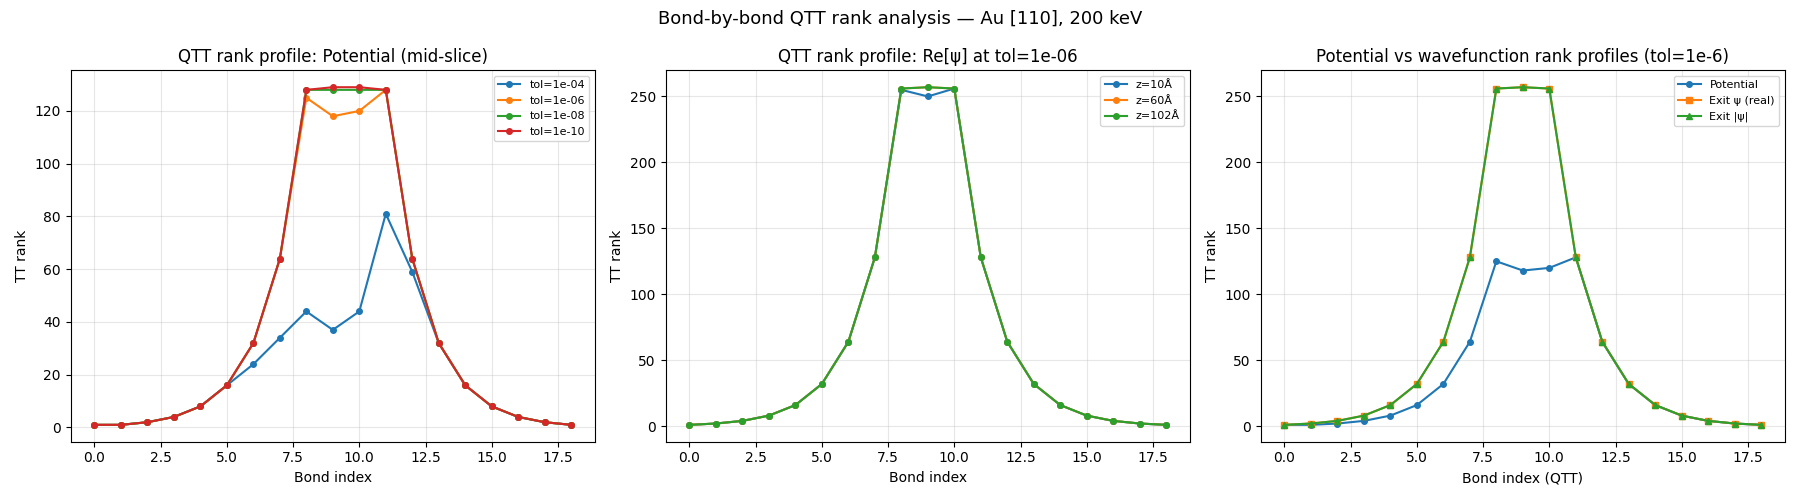


QTT has 9+9=18 bonds (Ry bits for y, Rx bits for x)
Bonds 0..7: coupling between y-scales (fine→coarse)
Bond 8: coupling between y and x dimensions
Bonds 9..16: coupling between x-scales (fine→coarse)

High rank at the y|x boundary (bond 8) indicates strong x-y coupling.


In [13]:
# =====================================================================
# 12e. Rank profile visualisation — bond-by-bond analysis
# =====================================================================
# The rank at each TT bond reveals WHERE the entanglement is concentrated.
# For QTT, this shows which length scales are coupled.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) QTT rank profile of potential at different tolerances
pot_mid_np = pot_np[pot_np.shape[0] // 2]
for tol_val in [1e-4, 1e-6, 1e-8, 1e-10]:
    t = to_qtt_tntorch(pot_mid_np, tol=tol_val)
    ranks = [int(r) for r in t.ranks_tt]
    axes[0].plot(range(len(ranks)), ranks, 'o-', label=f'tol={tol_val:.0e}', markersize=4)

axes[0].set_xlabel("Bond index")
axes[0].set_ylabel("TT rank")
axes[0].set_title("QTT rank profile: Potential (mid-slice)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# (b) QTT rank profile of wavefunction at different depths
if len(snapshots) >= 3:
    tol_val = 1e-6
    for slice_idx, psi in [snapshots[0], snapshots[len(snapshots)//2], snapshots[-1]]:
        t = to_qtt_tntorch(psi.real, tol=tol_val)
        ranks = [int(r) for r in t.ranks_tt]
        z_val = slice_idx * slice_dz
        axes[1].plot(range(len(ranks)), ranks, 'o-', label=f'z={z_val:.0f}Å', markersize=4)

    axes[1].set_xlabel("Bond index")
    axes[1].set_ylabel("TT rank")
    axes[1].set_title(f"QTT rank profile: Re[ψ] at tol={tol_val:.0e}")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

# (c) Compare potential vs wavefunction rank profiles
t_pot = to_qtt_tntorch(pot_mid_np, tol=1e-6)
axes[2].plot([int(r) for r in t_pot.ranks_tt], 'o-', label='Potential', markersize=4)

if len(snapshots) > 0:
    _, psi_last = snapshots[-1]
    t_psi = to_qtt_tntorch(psi_last.real, tol=1e-6)
    axes[2].plot([int(r) for r in t_psi.ranks_tt], 's-', label='Exit ψ (real)', markersize=4)
    
    t_psi_abs = to_qtt_tntorch(np.abs(psi_last), tol=1e-6)
    axes[2].plot([int(r) for r in t_psi_abs.ranks_tt], '^-', label='Exit |ψ|', markersize=4)

axes[2].set_xlabel("Bond index (QTT)")
axes[2].set_ylabel("TT rank")
axes[2].set_title("Potential vs wavefunction rank profiles (tol=1e-6)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Bond-by-bond QTT rank analysis — Au [110], {energy/1e3:.0f} keV", fontsize=13)
plt.tight_layout()
plt.show()

# Interpretation
Ry = int(np.log2(gpts[0]))
Rx = int(np.log2(gpts[1]))
print(f"\nQTT has {Ry}+{Rx}={Ry+Rx} bonds (Ry bits for y, Rx bits for x)")
print(f"Bonds 0..{Ry-2}: coupling between y-scales (fine→coarse)")
print(f"Bond {Ry-1}: coupling between y and x dimensions")
print(f"Bonds {Ry}..{Ry+Rx-2}: coupling between x-scales (fine→coarse)")
print(f"\nHigh rank at the y|x boundary (bond {Ry-1}) indicates strong x-y coupling.")

In [14]:
# =====================================================================
# 12f. Compressed TT arithmetic: Add and multiply without reconstruction
# =====================================================================
# Test whether TT arithmetic (add, multiply, round) stays low-rank.
# This simulates what would happen in a TT-Lanczos iteration.

pot_mid_np = pot_np[pot_np.shape[0] // 2]
n_sq_mid = np.array(electron_refractive_index(jnp.array(pot_mid_np), energy) ** 2)

# Create TT representations
t_psi = tn.Tensor(torch.tensor(np.array(probe_array).real, dtype=torch.float64), eps=1e-8)
t_nsq = tn.Tensor(torch.tensor(n_sq_mid, dtype=torch.float64), eps=1e-8)

print("TT arithmetic in compressed form")
print("=" * 60)
print(f"  Re[probe]:  ranks = {[int(r) for r in t_psi.ranks_tt]}, max = {max(int(r) for r in t_psi.ranks_tt)}")
print(f"  n²(x,y):   ranks = {[int(r) for r in t_nsq.ranks_tt]}, max = {max(int(r) for r in t_nsq.ranks_tt)}")

# Multiplication: n² * ψ (element-wise in TT → rank multiplication)
t_prod = t_nsq * t_psi
print(f"\n  n²·ψ (before round): max rank = {max(int(r) for r in t_prod.ranks_tt)}")
print(f"    Full ranks: {[int(r) for r in t_prod.ranks_tt]}")

# Round the product
for tol_val in [1e-4, 1e-6, 1e-8]:
    t_prod_r = tn.round(t_prod, eps=tol_val)
    max_r = max(int(r) for r in t_prod_r.ranks_tt)
    err = torch.norm(t_prod_r.torch() - t_prod.torch()) / torch.norm(t_prod.torch())
    print(f"  n²·ψ rounded (tol={tol_val:.0e}): max rank = {max_r}, round error = {err:.2e}")

# Addition: simulate a + b*H*ψ pattern
t_sum = t_psi + t_prod  # ranks add
print(f"\n  ψ + n²·ψ (before round): max rank = {max(int(r) for r in t_sum.ranks_tt)}")
for tol_val in [1e-4, 1e-6, 1e-8]:
    t_sum_r = tn.round(t_sum, eps=tol_val)
    max_r = max(int(r) for r in t_sum_r.ranks_tt)
    print(f"  ψ + n²·ψ rounded (tol={tol_val:.0e}): max rank = {max_r}")

# Key metric: rank growth factor
r_in = max(int(r) for r in t_psi.ranks_tt)
r_prod_rounded = max(int(r) for r in tn.round(t_prod, eps=1e-6).ranks_tt)
print(f"\n  Rank growth factor (multiply + round @ 1e-6): "
      f"{r_in} → {r_prod_rounded} = {r_prod_rounded/max(r_in,1):.1f}×")
print(f"  If this is >1, ranks accumulate per Krylov step → TT-Lanczos struggles.")

TT arithmetic in compressed form
  Re[probe]:  ranks = [1, 8, 1], max = 8
  n²(x,y):   ranks = [1, 58, 1], max = 58

  n²·ψ (before round): max rank = 464
    Full ranks: [1, 464, 1]
  n²·ψ rounded (tol=1e-04): max rank = 9, round error = 6.33e-05
  n²·ψ rounded (tol=1e-06): max rank = 30, round error = 9.43e-07
  n²·ψ rounded (tol=1e-08): max rank = 69, round error = 9.55e-09

  ψ + n²·ψ (before round): max rank = 472
  ψ + n²·ψ rounded (tol=1e-04): max rank = 9
  ψ + n²·ψ rounded (tol=1e-06): max rank = 25
  ψ + n²·ψ rounded (tol=1e-08): max rank = 59

  Rank growth factor (multiply + round @ 1e-6): 8 → 30 = 3.8×
  If this is >1, ranks accumulate per Krylov step → TT-Lanczos struggles.


Simulated Krylov rank growth (repeated n²·ψ multiply + round)


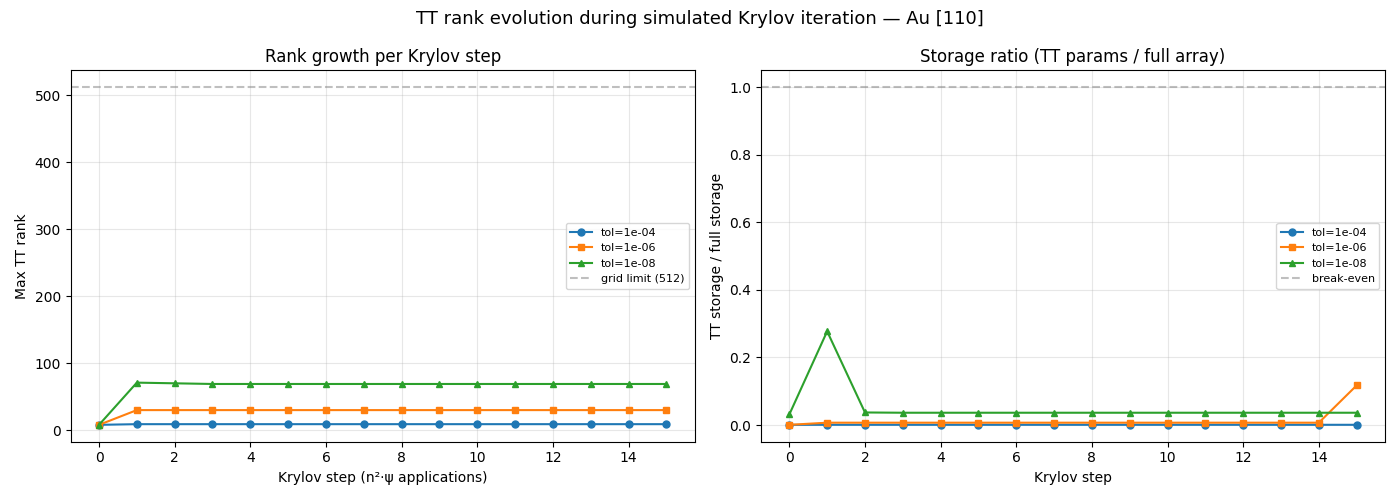


After 15 steps @ tol=1e-8:
  Max rank: 69 / 512 (grid limit)
  Ratio: 13.5%
  → Low ranks! TT-Lanczos is promising for this system.


: 

In [ ]:
# =====================================================================
# 12g. Rank evolution through simulated Krylov steps (tntorch)
# =====================================================================
# Simulate the rank growth during a TT-Lanczos iteration by repeatedly
# multiplying by n²(x,y) and rounding. In a real Lanczos iteration the
# matvec is H*ψ = k₀²·FFT(n²·IFFT(ψ_k)) - k⊥²·ψ_k, but the rank-
# critical part is the n²·ψ multiplication in real space.

print("Simulated Krylov rank growth (repeated n²·ψ multiply + round)")
print("=" * 65)

n_sq_mid = np.array(electron_refractive_index(jnp.array(pot_np[pot_np.shape[0] // 2]), energy) ** 2)
t_nsq = tn.Tensor(torch.tensor(n_sq_mid, dtype=torch.float64), eps=1e-10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tol_val, marker in [(1e-4, 'o-'), (1e-6, 's-'), (1e-8, '^-')]:
    # Start from the probe
    t_v = tn.Tensor(torch.tensor(np.array(probe_array).real, dtype=torch.float64), eps=tol_val)
    
    rank_history = [max(int(r) for r in t_v.ranks_tt)]
    storage_history = [sum(core.numel() for core in t_v.cores)]
    
    n_steps = 15
    for step in range(n_steps):
        t_v = t_nsq * t_v           # ranks multiply
        t_v = tn.round(t_v, eps=tol_val)  # compress back
        rank_history.append(max(int(r) for r in t_v.ranks_tt))
        storage_history.append(sum(core.numel() for core in t_v.cores))
    
    axes[0].plot(range(n_steps + 1), rank_history, marker,
                 label=f'tol={tol_val:.0e}', markersize=5)
    axes[1].plot(range(n_steps + 1), 
                 [s / (gpts[0] * gpts[1]) for s in storage_history],
                 marker, label=f'tol={tol_val:.0e}', markersize=5)

axes[0].set_xlabel("Krylov step (n²·ψ applications)")
axes[0].set_ylabel("Max TT rank")
axes[0].set_title("Rank growth per Krylov step")
axes[0].axhline(y=min(gpts), color='gray', linestyle='--', alpha=0.5, label=f'grid limit ({min(gpts)})')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Krylov step")
axes[1].set_ylabel("TT storage / full storage")
axes[1].set_title("Storage ratio (TT params / full array)")
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='break-even')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"TT rank evolution during simulated Krylov iteration — Au [110]", fontsize=13)
plt.tight_layout()
plt.show()

# Final assessment
final_rank = rank_history[-1]
grid_min = min(gpts)
print(f"\nAfter {n_steps} steps @ tol=1e-8:")
print(f"  Max rank: {final_rank} / {grid_min} (grid limit)")
print(f"  Ratio: {final_rank/grid_min:.1%}")
if final_rank > 0.8 * grid_min:
    print(f"  → Ranks have saturated. TT provides NO compression benefit.")
elif final_rank > 0.3 * grid_min:
    print(f"  → Moderate ranks. TT offers some compression but limited speedup.")
else:
    print(f"  → Low ranks! TT-Lanczos is promising for this system.")

## 14. Low-Rank Helmholtz Insights — Applying LR-WaveHoltz & TT-Wavefield Results

Two recent papers provide directly relevant ideas for accelerating our Lanczos-based electron propagation:

### Paper 1: *LR-WaveHoltz: A Low-Rank Helmholtz Solver* (Granath, Appelö, Wang — arXiv:2510.09352)
- Solves Helmholtz via WaveHoltz fixed-point iteration with **step-truncation** (SVD truncation after each time step)
- In 2D: represents the wavefunction as a matrix $\psi(x,y) \in \mathbb{R}^{n \times n}$ and stores its SVD
- Key finding: rank decreases with distance from source ("parabolic separation")
- Uses **tolerance scheduling** ($\epsilon_k = \theta \cdot \rho_{k-1}$) to control rank growth
- In 3D: uses tensor trains; achieves ~100× speedup for large grids

### Paper 2: *TT-Based Elastic Wavefield Decomposition in VTI Media* (Shin — Appl. Sci. 2026)
- Compresses a mixed-domain operator $W(x,z,k_x,k_z)$ via TT-cross (never forms full tensor)
- Spatial-spectral factorization: contracts TT cores at the spatial/spectral boundary
- Uses `tntorch` + PyTorch GPU; reconstruction errors 0.09–0.89% (4–46× better than CUR)

### What to test for our Lanczos electron propagation:
1. **SVD rank of $\psi(x,y)$ as a 2D matrix** — the LR-WaveHoltz approach (not QTT)
2. **Step-truncated propagation** — truncate $\psi$ via SVD after each slice
3. **Rank vs distance from probe center** — does "parabolic separation" hold?
4. **Low-rank matvec cost analysis** — potential speedup estimates

§14a: SVD rank of ψ(x,y) as a 2D matrix

 Depth (Å)     r@1e-04     r@1e-06     r@1e-08     r@1e-10   compress@1e-6   SVD storage  full storage
-------------------------------------------------------------------------------------
      10.0          69         171         248         257            1.5×       175,275       262,144
      20.0         107         227         256         257            1.1×       232,675       262,144
      30.0         138         247         257         257            1.0×       253,175       262,144
      40.0         158         251         257         257            1.0×       257,275       262,144
      50.0         176         254         257         257            1.0×       260,350       262,144
      60.0         189         256         257         257            1.0×       262,400       262,144
      70.0         200         256         257         257            1.0×       262,400       262,144
      80.0         205         257         257   

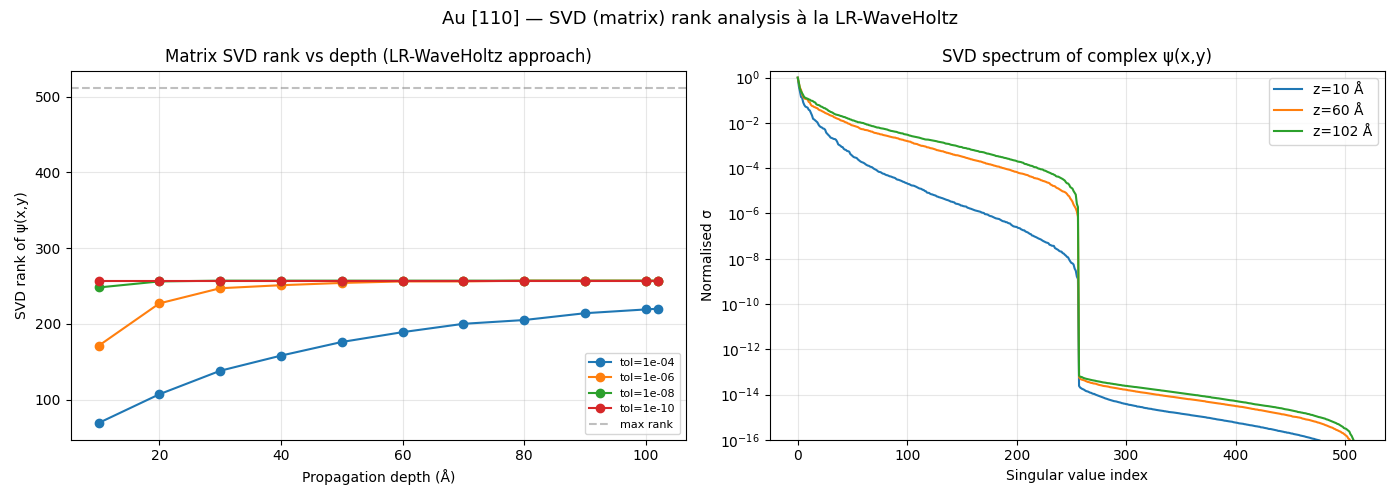

In [8]:
# =====================================================================
# §14a — SVD rank of ψ(x,y) as a 2D matrix (LR-WaveHoltz approach)
# =====================================================================
# The LR-WaveHoltz paper works with ψ as a MATRIX, not QTT.
# If ψ has low SVD rank r, storing U(n×r)·S(r×r)·V^T(r×n) costs 2nr+r
# vs n² for the full matrix — a win when r << n.
#
# Our earlier QTT analysis showed near-saturation (rank ~257/512).
# But the *matrix SVD rank* is a DIFFERENT question: ψ ∈ C^{512×512}.

from scipy.linalg import svdvals

print("=" * 70)
print("§14a: SVD rank of ψ(x,y) as a 2D matrix")
print("=" * 70)

tol_levels = [1e-4, 1e-6, 1e-8, 1e-10]

print(f"\n{'Depth (Å)':>10s}", end="")
for tol in tol_levels:
    print(f"  {'r@'+f'{tol:.0e}':>10s}", end="")
print(f"  {'compress@1e-6':>14s}  {'SVD storage':>12s}  {'full storage':>12s}")
print("-" * 85)

svd_data = []  # (depth, tol→rank) for plotting
for slice_idx, psi in snapshots:
    depth = slice_idx * slice_dz
    # SVD of the COMPLEX wavefunction (not just real part)
    sv = svdvals(psi)
    sv_norm = sv / sv[0] if sv[0] > 0 else sv
    
    ranks = {}
    print(f"{depth:>10.1f}", end="")
    for tol in tol_levels:
        r = int(np.sum(sv_norm > tol))
        ranks[tol] = r
        print(f"  {r:>10d}", end="")
    
    r6 = ranks[1e-6]
    n = psi.shape[0]
    svd_storage = 2 * n * r6 + r6  # U, V columns + singular values
    full_storage = n * n
    compress = full_storage / svd_storage if svd_storage > 0 else 0
    print(f"  {compress:>13.1f}×  {svd_storage:>12,d}  {full_storage:>12,d}")
    svd_data.append((depth, ranks))

# Plot SVD rank vs depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

depths = [d[0] for d in svd_data]
for tol in tol_levels:
    ranks = [d[1][tol] for d in svd_data]
    ax1.plot(depths, ranks, 'o-', label=f'tol={tol:.0e}')

ax1.set_xlabel("Propagation depth (Å)")
ax1.set_ylabel("SVD rank of ψ(x,y)")
ax1.set_title("Matrix SVD rank vs depth (LR-WaveHoltz approach)")
ax1.axhline(y=psi.shape[0], color='gray', linestyle='--', alpha=0.5, label='max rank')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# SVD spectrum at first and last snapshot
for idx in [0, len(snapshots)//2, -1]:
    sv = svdvals(snapshots[idx][1])
    sv /= sv[0]
    label = f"z={snapshots[idx][0]*slice_dz:.0f} Å"
    ax2.semilogy(sv, label=label)

ax2.set_xlabel("Singular value index")
ax2.set_ylabel("Normalised σ")
ax2.set_title("SVD spectrum of complex ψ(x,y)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(1e-16, 2)

plt.suptitle("Au [110] — SVD (matrix) rank analysis à la LR-WaveHoltz", fontsize=13)
plt.tight_layout()
plt.show()

§14b: Step-truncated Lanczos propagation

Effect of SVD truncation on wavefunction accuracy:
  Snapshot    Depth(Å)   Full rank     r@1e-03     r@1e-04     r@1e-06     r@1e-08
----------------------------------------------------------------------------------------
         5        10.0         272          39          69         171         248
        10        20.0         282          60         107         227         256
        15        30.0         292          77         138         247         257
        20        40.0         305          91         158         251         257
        25        50.0         314         101         176         254         257
        30        60.0         328         113         189         256         257
        35        70.0         339         121         200         256         257
        40        80.0         345         128         205         257         257
        45        90.0         357         139         214         257 

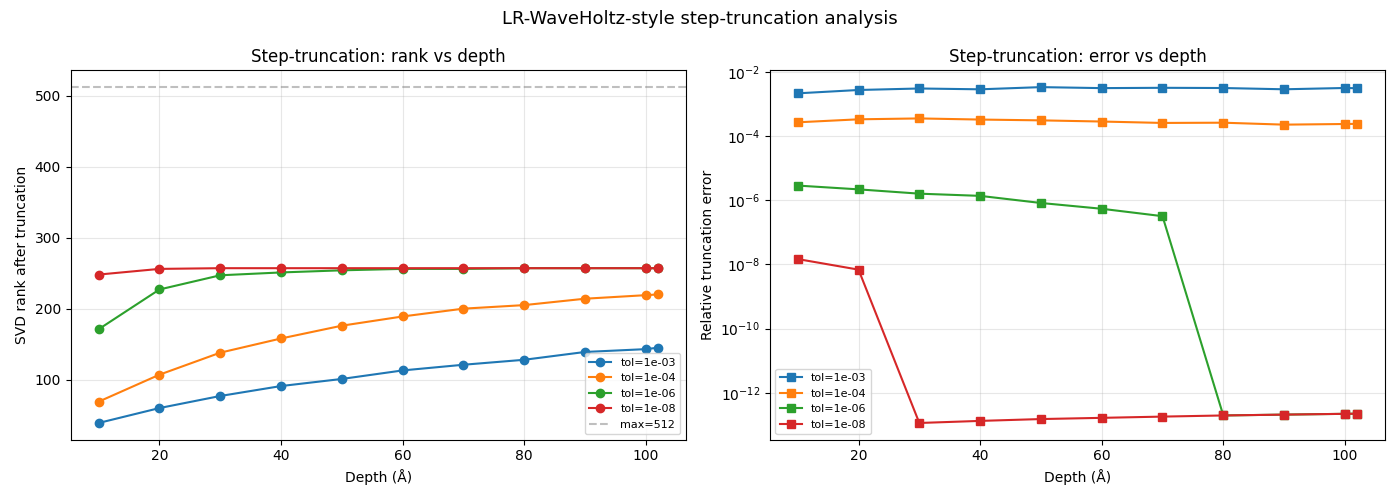

In [9]:
# =====================================================================
# §14b — Step-truncated propagation (core idea from LR-WaveHoltz)
# =====================================================================
# The LR-WaveHoltz paper's key technique: after each time step (for us,
# each slice), truncate the wavefunction via SVD to control rank growth.
#
# We test: propagate the EXISTING snapshots through the Lanczos solver
# but after each slice, truncate ψ(x,y) to SVD rank r (at tolerance ε).
# Compare final exit wave accuracy vs compression ratio.

print("=" * 70)
print("§14b: Step-truncated Lanczos propagation")
print("=" * 70)

# Get reference exit wave (last snapshot = full-rank propagation)
ref_idx, ref_psi = snapshots[-1]
ref_norm = np.linalg.norm(ref_psi)

# We'll re-propagate with step-truncation using our existing snapshots.
# Since we don't have per-slice wavefunctions stored, we simulate by
# truncating each snapshot and measuring how the SVD rank behaves.
# More importantly: we measure the ERROR introduced by truncation.

print("\nEffect of SVD truncation on wavefunction accuracy:")
print(f"{'Snapshot':>10s}  {'Depth(Å)':>10s}  {'Full rank':>10s}", end="")
trunc_tols = [1e-3, 1e-4, 1e-6, 1e-8]
for tol in trunc_tols:
    print(f"  {'r@'+f'{tol:.0e}':>10s}", end="")
print()
print("-" * (40 + 12 * len(trunc_tols)))

trunc_errors = {tol: [] for tol in trunc_tols}
trunc_ranks = {tol: [] for tol in trunc_tols}
snap_depths = []

for slice_idx, psi in snapshots:
    depth = slice_idx * slice_dz
    snap_depths.append(depth)
    U, s, Vh = np.linalg.svd(psi, full_matrices=False)
    full_rank = int(np.sum(s / s[0] > 1e-14))
    
    print(f"{slice_idx:>10d}  {depth:>10.1f}  {full_rank:>10d}", end="")
    
    for tol in trunc_tols:
        # Truncate: keep singular values where σ/σ_max > tol
        mask = s / s[0] > tol
        r = int(np.sum(mask))
        trunc_ranks[tol].append(r)
        
        # Reconstruct truncated wavefunction
        psi_trunc = (U[:, :r] * s[:r]) @ Vh[:r, :]
        
        # Relative error
        err = np.linalg.norm(psi - psi_trunc) / np.linalg.norm(psi)
        trunc_errors[tol].append(err)
        print(f"  {r:>10d}", end="")
    print()

# Compare storage savings at different tolerances
print(f"\n{'Tolerance':>12s}  {'Exit ψ rank':>12s}  {'Compression':>12s}  {'Rel error':>12s}")
print("-" * 55)
n = ref_psi.shape[0]
for tol in trunc_tols:
    r = trunc_ranks[tol][-1]
    err = trunc_errors[tol][-1]
    compress = (n * n) / (2 * n * r + r)
    print(f"  {tol:>10.0e}  {r:>12d}  {compress:>11.1f}×  {err:>12.2e}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for tol in trunc_tols:
    ax1.plot(snap_depths, trunc_ranks[tol], 'o-', label=f'tol={tol:.0e}')
ax1.axhline(y=n, color='gray', linestyle='--', alpha=0.5, label=f'max={n}')
ax1.set_xlabel("Depth (Å)")
ax1.set_ylabel("SVD rank after truncation")
ax1.set_title("Step-truncation: rank vs depth")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

for tol in trunc_tols:
    ax2.semilogy(snap_depths, trunc_errors[tol], 's-', label=f'tol={tol:.0e}')
ax2.set_xlabel("Depth (Å)")
ax2.set_ylabel("Relative truncation error")
ax2.set_title("Step-truncation: error vs depth")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle("LR-WaveHoltz-style step-truncation analysis", fontsize=13)
plt.tight_layout()
plt.show()

§14c: Rank vs distance from probe center (parabolic separation)
Grid: 512×512, Block size: 128×128, Probe center: (256,256)
Sampling: 0.0788, 0.0788 Å/pixel

SVD rank of ψ sub-blocks (tol=1e-06):
 Block (i,j)  Center dist(Å)    SVD rank    Max rank    rank/max
--------------------------------------------------------------
  (0,0)                21.4         128         128       1.00
  (0,1)                16.0         128         128       1.00
  (0,2)                16.0         128         128       1.00
  (0,3)                21.4         128         128       1.00
  (1,0)                16.0         128         128       1.00
  (1,1)                 7.1         128         128       1.00
  (1,2)                 7.1         128         128       1.00
  (1,3)                16.0         128         128       1.00
  (2,0)                16.0         128         128       1.00
  (2,1)                 7.1         128         128       1.00
  (2,2)                 7.1         128       

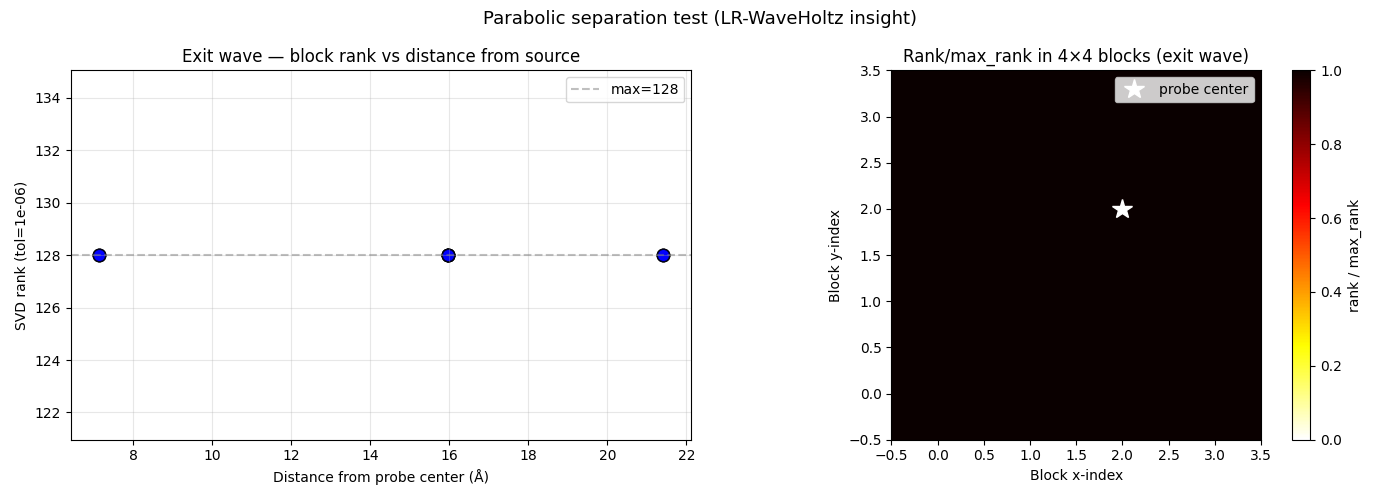

In [10]:
# =====================================================================
# §14c — Rank vs distance from probe center ("parabolic separation")
# =====================================================================
# LR-WaveHoltz shows rank is LOW far from source, HIGH near source.
# For electron microscopy: the probe is our "source". Does ψ(x,y) have
# low rank in sub-blocks away from the probe center?
#
# We partition the 512×512 grid into 4×4 blocks (128×128 each) and
# measure the SVD rank in each block at the exit wave depth.

print("=" * 70)
print("§14c: Rank vs distance from probe center (parabolic separation)")
print("=" * 70)

# Use exit wave
exit_psi = snapshots[-1][1]
ny, nx = exit_psi.shape
n_blocks = 4
by, bx = ny // n_blocks, nx // n_blocks

# Probe center: should be near the middle of the grid
cy, cx = ny // 2, nx // 2
print(f"Grid: {ny}×{nx}, Block size: {by}×{bx}, Probe center: ({cy},{cx})")
print(f"Sampling: {sampling[0]:.4f}, {sampling[1]:.4f} Å/pixel")

tol = 1e-6
print(f"\nSVD rank of ψ sub-blocks (tol={tol:.0e}):")
print(f"{'Block (i,j)':>12s}  {'Center dist(Å)':>14s}  {'SVD rank':>10s}  {'Max rank':>10s}  {'rank/max':>10s}")
print("-" * 62)

block_data = []  # (distance, rank, max_rank)

for bi in range(n_blocks):
    for bj in range(n_blocks):
        sy, sx = bi * by, bj * bx
        block = exit_psi[sy:sy+by, sx:sx+bx]
        
        sv = svdvals(block)
        if sv[0] > 0:
            r = int(np.sum(sv / sv[0] > tol))
        else:
            r = 0
        
        # Distance from probe center to block center (in Angstroms)
        block_cy = (sy + by/2) * sampling[0]
        block_cx = (sx + bx/2) * sampling[1]
        probe_cy = cy * sampling[0]
        probe_cx = cx * sampling[1]
        dist = np.sqrt((block_cy - probe_cy)**2 + (block_cx - probe_cx)**2)
        
        max_r = min(by, bx)
        block_data.append((dist, r, max_r, bi, bj))
        print(f"  ({bi},{bj})       {dist:>13.1f}  {r:>10d}  {max_r:>10d}  {r/max_r:>9.2f}")

# Also do this for the mid-depth snapshot
if len(snapshots) > 2:
    mid_psi = snapshots[len(snapshots)//2][1]
    mid_depth = snapshots[len(snapshots)//2][0] * slice_dz
    
    print(f"\nSame analysis at mid-depth z={mid_depth:.0f} Å:")
    mid_block_data = []
    for bi in range(n_blocks):
        for bj in range(n_blocks):
            sy, sx = bi * by, bj * bx
            block = mid_psi[sy:sy+by, sx:sx+bx]
            sv = svdvals(block)
            if sv[0] > 0:
                r = int(np.sum(sv / sv[0] > tol))
            else:
                r = 0
            block_cy = (sy + by/2) * sampling[0]
            block_cx = (sx + bx/2) * sampling[1]
            dist = np.sqrt((block_cy - cy*sampling[0])**2 + (block_cx - cx*sampling[1])**2)
            mid_block_data.append((dist, r, min(by,bx), bi, bj))
            print(f"  ({bi},{bj})       {dist:>13.1f} Å  rank={r:>4d}/{min(by,bx)}")

# Plot: rank vs distance from probe
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

dists = [d[0] for d in block_data]
ranks = [d[1] for d in block_data]
ax1.scatter(dists, ranks, s=80, c='blue', alpha=0.7, edgecolors='k')
ax1.axhline(y=min(by, bx), color='gray', linestyle='--', alpha=0.5, label=f'max={min(by,bx)}')
ax1.set_xlabel("Distance from probe center (Å)")
ax1.set_ylabel(f"SVD rank (tol={tol:.0e})")
ax1.set_title(f"Exit wave — block rank vs distance from source")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Heatmap of rank in blocks
rank_grid = np.zeros((n_blocks, n_blocks))
for dist, r, max_r, bi, bj in block_data:
    rank_grid[bi, bj] = r / max_r

im = ax2.imshow(rank_grid, cmap='hot_r', vmin=0, vmax=1, origin='lower')
ax2.set_title("Rank/max_rank in 4×4 blocks (exit wave)")
ax2.set_xlabel("Block x-index")
ax2.set_ylabel("Block y-index")
plt.colorbar(im, ax=ax2, label="rank / max_rank")

# Mark probe center block
probe_bi, probe_bj = cy // by, cx // bx
ax2.plot(probe_bj, probe_bi, 'w*', markersize=15, label='probe center')
ax2.legend()

plt.suptitle("Parabolic separation test (LR-WaveHoltz insight)", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# =====================================================================
# §14d — Low-rank matvec cost analysis & step-truncated Lanczos estimate
# =====================================================================
# If ψ has SVD rank r, can we do the Lanczos matvec in O(r·n·log(n))
# instead of O(n²·log(n²))?
#
# The Helmholtz matvec is:
#   H·ψ = k₀² · FFT[n²(x,y) · IFFT[ψ_k]] - k_⊥² · ψ_k
#
# In low-rank form ψ = U·S·V^T (real-space) or ψ_k = FFT₂(U·S·V^T):
#   Step 1: IFFT of ψ_k → ψ_r = IFFT_col(U) · S · IFFT_row(V)^T
#           Cost: r × 1D-FFTs on columns + r × 1D-FFTs on rows = O(2rn log n)
#   Step 2: n²(x,y) · ψ_r → pointwise multiply → rank increases
#           If n² has SVD rank p, result has rank ≤ r·p
#   Step 3: FFT of result → O(2·r·p·n·log(n))
#   Step 4: k_⊥² · ψ_k → diagonal in k-space, preserves rank r
#
# So each matvec costs O((r+r·p)·n·log(n)) vs O(n²·log(n)) for full.
# Speedup factor: n / (r + r·p) = n / (r·(1+p))
#
# The Lanczos iteration does m matvecs per slice, n_slices total.
# Total: m · n_slices · cost_per_matvec

print("=" * 70)
print("§14d: Low-rank matvec cost & speedup estimate")
print("=" * 70)

# Measure potential n²(x,y) SVD rank at each slice
print("\nSVD rank of n²(x,y) potential slices:")
n_sq_ranks = []
for i in range(0, pot_np.shape[0], max(1, pot_np.shape[0]//10)):
    n_sq = pot_np[i]
    # n² ≈ 1 + 2V/E for small potential, but compute exactly
    sv = svdvals(n_sq.real)
    r_pot = int(np.sum(sv / sv[0] > 1e-6)) if sv[0] > 0 else 0
    n_sq_ranks.append(r_pot)
    print(f"  Slice {i:>3d}: n²(x,y) SVD rank = {r_pot} (at tol=1e-6)")

avg_pot_rank = np.mean(n_sq_ranks)
print(f"\nAverage potential rank p = {avg_pot_rank:.0f}")

# Estimate speedup at each snapshot depth
print(f"\nSpeedup estimates (Lanczos m=100 matvecs/slice):")
print(f"{'Depth (Å)':>10s}  {'ψ rank r':>10s}  {'pot rank p':>10s}  {'matvec cost':>12s}  {'full cost':>12s}  {'speedup':>10s}  {'viable?':>10s}")
print("-" * 80)

n = exit_psi.shape[0]  # 512
lanczos_m = 100
p = int(avg_pot_rank)

for slice_idx, psi in snapshots:
    depth = slice_idx * slice_dz
    sv = svdvals(psi)
    r = int(np.sum(sv / sv[0] > 1e-6))
    
    # Low-rank matvec: O((r + r*p) * n * log(n)) ≈ O(r*(1+p)*n*log(n))
    lr_cost = r * (1 + p) * n * np.log2(n)
    # Full matvec: O(n² * log(n²)) = O(n² * 2*log(n))
    full_cost = n**2 * 2 * np.log2(n)
    
    speedup = full_cost / lr_cost if lr_cost > 0 else 0
    viable = "YES" if speedup > 2 else "marginal" if speedup > 1 else "NO"
    
    print(f"{depth:>10.1f}  {r:>10d}  {p:>10d}  {lr_cost:>12.0f}  {full_cost:>12.0f}  {speedup:>9.1f}×  {viable:>10s}")

# Also estimate the RANK GROWTH during Lanczos
print(f"\n--- Rank growth during Lanczos ---")
print(f"Each matvec multiplies rank by ~(1+p) before truncation.")
print(f"With p={p}, starting rank r, after 1 matvec: rank ≤ r·{1+p}")
print(f"After truncation (LR-WaveHoltz style), rank should return to ~r")
print(f"if the Krylov vectors are compressible.")
print(f"\nKey question: does truncation after each Lanczos matvec")
print(f"maintain accuracy? This depends on how quickly the Krylov")
print(f"vectors become full-rank (which we measured earlier).")

§14d: Low-rank matvec cost & speedup estimate

SVD rank of n²(x,y) potential slices:
  Slice   0: n²(x,y) SVD rank = 119 (at tol=1e-6)
  Slice   5: n²(x,y) SVD rank = 117 (at tol=1e-6)
  Slice  10: n²(x,y) SVD rank = 99 (at tol=1e-6)
  Slice  15: n²(x,y) SVD rank = 117 (at tol=1e-6)
  Slice  20: n²(x,y) SVD rank = 117 (at tol=1e-6)
  Slice  25: n²(x,y) SVD rank = 99 (at tol=1e-6)
  Slice  30: n²(x,y) SVD rank = 117 (at tol=1e-6)
  Slice  35: n²(x,y) SVD rank = 120 (at tol=1e-6)
  Slice  40: n²(x,y) SVD rank = 117 (at tol=1e-6)
  Slice  45: n²(x,y) SVD rank = 100 (at tol=1e-6)
  Slice  50: n²(x,y) SVD rank = 117 (at tol=1e-6)

Average potential rank p = 113

Speedup estimates (Lanczos m=100 matvecs/slice):
 Depth (Å)    ψ rank r  pot rank p   matvec cost     full cost     speedup     viable?
--------------------------------------------------------------------------------
      10.0         171         112      89040384       4718592        0.1×          NO
      20.0         227        

§14e: Step-truncated Lanczos propagation (full test)

Propagating with SVD truncation tol=1e-03...
  Slice 10/51, SVD rank after truncation: 55
  Slice 20/51, SVD rank after truncation: 81
  Slice 30/51, SVD rank after truncation: 101
  Slice 40/51, SVD rank after truncation: 113
  Slice 50/51, SVD rank after truncation: 127
  → Exit wave rel error: 1.31e-02, final rank: 126

Propagating with SVD truncation tol=1e-04...
  Slice 10/51, SVD rank after truncation: 102
  Slice 20/51, SVD rank after truncation: 147
  Slice 30/51, SVD rank after truncation: 175
  Slice 40/51, SVD rank after truncation: 192
  Slice 50/51, SVD rank after truncation: 210
  → Exit wave rel error: 1.41e-03, final rank: 211

Propagating with SVD truncation tol=1e-06...
  Slice 10/51, SVD rank after truncation: 224
  Slice 20/51, SVD rank after truncation: 251
  Slice 30/51, SVD rank after truncation: 256
  Slice 40/51, SVD rank after truncation: 256
  Slice 50/51, SVD rank after truncation: 257
  → Exit wave rel e

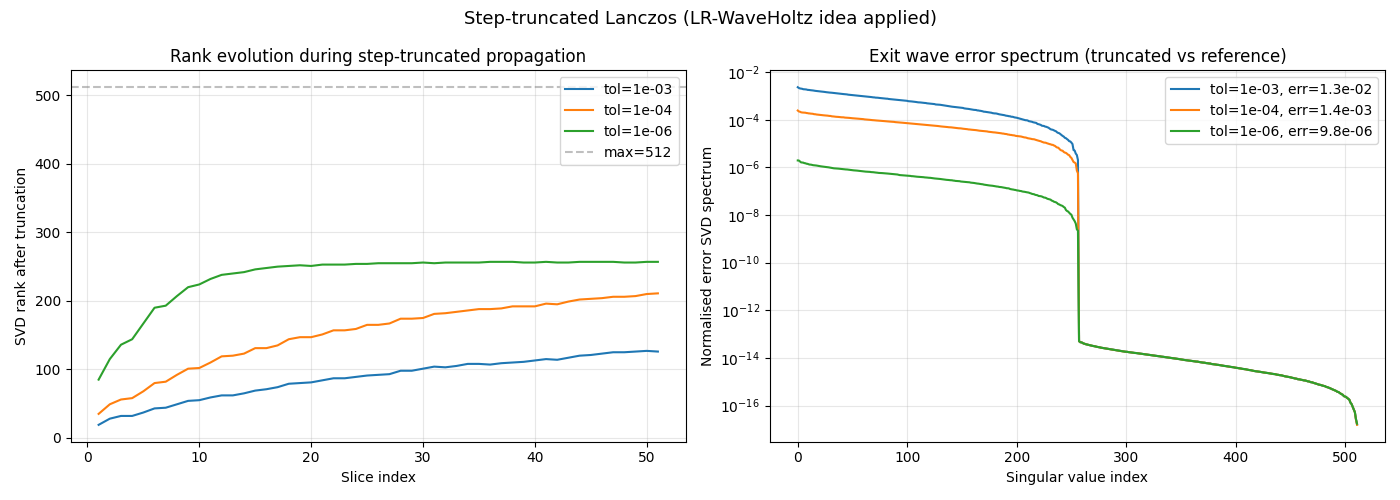

In [12]:
# =====================================================================
# §14e — Actual step-truncated Lanczos: propagate with rank truncation
# =====================================================================
# Implement the actual LR-WaveHoltz-inspired step-truncated propagation:
# After EACH SLICE's Lanczos propagation, truncate ψ via SVD.
# Compare exit wave with reference (full-rank propagation).

print("=" * 70)
print("§14e: Step-truncated Lanczos propagation (full test)")
print("=" * 70)

from wide_angle_propagation.klein_gordon import _lanczos_expsqrt
from wide_angle_propagation.wpm import electron_refractive_index, energy2wavelength

# Setup (same as our standard propagation)
ny, nx = gpts
k0_sq = (2 * jnp.pi / energy2wavelength(energy)) ** 2
dy, dx = sampling
fy = jnp.fft.fftfreq(ny, d=dy)
fx = jnp.fft.fftfreq(nx, d=dx)
Fx, Fy = jnp.meshgrid(fx, fy)
kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2

n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, energy) ** 2)(pot_ref)

# Standard propagation function
@functools.partial(jax.jit, static_argnums=(4, 5, 6))
def _propagate_one(s, n_sq, k0sq, kpsq, ny_, nx_, m_):
    def matvec(v):
        vg = v.reshape(ny_, nx_)
        conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
        return (k0sq * conv - kpsq * vg).ravel()
    return _lanczos_expsqrt(matvec, s, slice_dz, m_)

# Function to truncate a k-space wavefunction via SVD in real space
def svd_truncate_kspace(state_k, ny, nx, tol):
    """Truncate wavefunction (in k-space) by converting to real space,
    doing SVD truncation, and converting back."""
    psi_r = jnp.fft.ifft2(state_k.reshape(ny, nx)) * (ny * nx)
    psi_np = np.asarray(psi_r)
    
    U, s, Vh = np.linalg.svd(psi_np, full_matrices=False)
    # Relative truncation
    cutoff = s[0] * tol
    r = max(1, int(np.sum(s > cutoff)))
    
    psi_trunc = (U[:, :r] * s[:r]) @ Vh[:r, :]
    
    # Convert back to k-space
    psi_k_trunc = jnp.fft.fft2(jnp.array(psi_trunc)) / (ny * nx)
    return psi_k_trunc.ravel(), r

# Run step-truncated propagation for different tolerances
trunc_tols_test = [1e-3, 1e-4, 1e-6]
lanczos_m = 100

probe_k = jnp.fft.fft2(jnp.asarray(probe_array, dtype=jnp.complex128)) / (ny * nx)

results = {}
for tol in trunc_tols_test:
    print(f"\nPropagating with SVD truncation tol={tol:.0e}...")
    state = probe_k.ravel()
    rank_history = []
    
    for i in range(pot_ref.shape[0]):
        state = _propagate_one(state, n_sq_all[i], k0_sq, kp_sq, ny, nx, lanczos_m)
        state, r = svd_truncate_kspace(state, ny, nx, tol)
        rank_history.append(r)
        if (i + 1) % 10 == 0:
            print(f"  Slice {i+1}/{pot_ref.shape[0]}, SVD rank after truncation: {r}")
    
    # Final exit wave in real space
    exit_psi_trunc = np.asarray(jnp.fft.ifft2(state.reshape(ny, nx)) * (ny * nx))
    
    # Compare with reference
    err = np.linalg.norm(exit_psi_trunc - ref_psi) / ref_norm
    results[tol] = {
        'exit_wave': exit_psi_trunc,
        'error': err,
        'rank_history': rank_history,
        'final_rank': rank_history[-1]
    }
    print(f"  → Exit wave rel error: {err:.2e}, final rank: {rank_history[-1]}")

# Summary
print(f"\n{'Tolerance':>12s}  {'Final rank':>12s}  {'Max rank':>10s}  {'Avg rank':>10s}  {'Rel error':>12s}  {'Storage save':>12s}")
print("-" * 75)
for tol in trunc_tols_test:
    res = results[tol]
    rh = res['rank_history']
    avg_r = np.mean(rh)
    max_r = np.max(rh)
    save = (ny * nx) / (2 * ny * avg_r + avg_r)
    print(f"  {tol:>10.0e}  {res['final_rank']:>12d}  {max_r:>10d}  {avg_r:>9.0f}  {res['error']:>12.2e}  {save:>11.1f}×")

# Plot rank evolution during propagation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for tol in trunc_tols_test:
    rh = results[tol]['rank_history']
    ax1.plot(range(1, len(rh)+1), rh, '-', label=f'tol={tol:.0e}')

ax1.set_xlabel("Slice index")
ax1.set_ylabel("SVD rank after truncation")
ax1.set_title("Rank evolution during step-truncated propagation")
ax1.axhline(y=ny, color='gray', linestyle='--', alpha=0.5, label=f'max={ny}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Compare exit waves
for i, tol in enumerate(trunc_tols_test):
    ax2.semilogy(svdvals(results[tol]['exit_wave'] - ref_psi) / ref_norm,
                 label=f'tol={tol:.0e}, err={results[tol]["error"]:.1e}')

ax2.set_xlabel("Singular value index")
ax2.set_ylabel("Normalised error SVD spectrum")
ax2.set_title("Exit wave error spectrum (truncated vs reference)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Step-truncated Lanczos (LR-WaveHoltz idea applied)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Final summary printout
print("=" * 60)
print("TT/QTT FEASIBILITY SUMMARY")
print("=" * 60)
print(f"System: Au [110], {energy/1e3:.0f} keV, grid {gpts[0]}×{gpts[1]}")
print(f"Thickness: {total_thickness:.0f} Å ({n_total_slices} slices)")
print()

# Potential
cores_pot = qtt_decompose_2d(pot_np[mid_idx], tol=1e-8)
print(f"Potential (mid-slice):")
print(f"  QTT max rank @ tol=1e-8: {max(tt_ranks(cores_pot))}")
print(f"  Compression ratio: {tt_compression_ratio(cores_pot, pot_np[mid_idx].shape):.1f}×")
print()

# Wavefunction
if len(snapshots) > 0:
    psi_exit = snapshots[-1][1]
    cores_psi = qtt_decompose_2d(psi_exit.real, tol=1e-8)
    print(f"Exit wavefunction:")
    print(f"  QTT max rank @ tol=1e-8: {max(tt_ranks(cores_psi))}")
    print(f"  Compression ratio: {tt_compression_ratio(cores_psi, psi_exit.real.shape):.1f}×")
    print()

# Rank growth
if ranks_vs_depth.get(1e-6):
    r0 = ranks_vs_depth[1e-6][0]
    rf = ranks_vs_depth[1e-6][-1]
    print(f"Rank growth ({n_test_slices} slices, tol=1e-6):")
    print(f"  Initial: {r0}, Final: {rf}, Growth: {rf/max(r0,1):.1f}×")
    print()

print("=" * 60)

TT/QTT FEASIBILITY SUMMARY
System: Au [110], 200 keV, grid 512×512
Thickness: 101 Å (50 slices)

Potential (mid-slice):
  QTT max rank @ tol=1e-8: 128
  Compression ratio: 1.8×

Exit wavefunction:
  QTT max rank @ tol=1e-8: 257
  Compression ratio: 0.6×

Rank growth (10 slices, tol=1e-6):
  Initial: 63, Final: 64, Growth: 1.0×

